# NVDA Price Forecast - June 08 to June 12 2026
---
# Team Information
- **Team Nickname:** QuantX
| Name | Student Number |
| --- | --- |
| **Muhammad Haseeb Qamar** | 148733 |
---
# Model's Method Description
We built a **multi-model ensemble** for 5-day ahead NVDA close price forecasting. 

| Model | Role |
| --- | --- |
| **LightGBM** | Primary model, gradient boosted trees on technical indicators |
| **XGBoost** | Secondry tree model - ensemble partner |
| **LSTM + Attention** | Deep Learning Model - captures sequential price pattern |
| **TFT (Temporal Fusion Trasnformer**) | State-of-the-art attetnion mechanism with a Varaiable Selection Network |
| **FinBERT Sentiment** | NLP Signal - NVIDIA news sentiment as a feature |   

**Variables Used:** Open, High, Low, Close, Volume, RS(14), MACD, Bollinger Bands, EMA(9/21/50), ATR, Stochastic Oscillator, lag features (1/2/3/5 days), rolling mean/std, volume ratio, day-of-week, FinBERT news sentiment score.

**Validation Strategy:** Walk forward time-series cross-validation (no data leakage - future data never used to train past predictions).

---

In [0]:
# Configuration

DATA_START_DATE = '2024-01-01'
DATA_END_DATE = '2026-06-07'
end = '2026-06-08'

TICKER = 'NVDA'
FORECAST_DAYS = 5
RANDOM_SEED = 42

# Ensemble Weights (LightGBM, XGBoost, TFT)
ENSEMBLE_WEIGHTS = [0.30, 0.20, 0.20, 0.30]

print (f'Config Loaded, FORECASTING 5 Days')

Config Loaded, FORECASTING 5 Days


In [0]:
# Imports

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

# Data
import yfinance as yf

# Technical Indicators 
import ta

# Tree Models
import lightgbm as lgb
import xgboost as xgb

# Sklearn Utilities 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# NLP
from transformers import pipeline

print ('All imports Successful')

import os, random
SEED = RANDOM_SEED  # 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print('Global seeds set')

All imports Successful
Global seeds set


---
# Data Downloading and Featuring 
---

In [0]:
# Data Downloading

DOWNLOAD_LIVE = False

FROZEN_OHLCV = [("2024-01-02", 49.16, 49.21, 47.51, 48.08, 411254000),
    ("2024-01-03", 47.40, 48.10, 47.24, 47.48, 320896000),
    ("2024-01-04", 47.68, 48.41, 47.42, 47.91, 306535000),
    ("2024-01-05", 48.38, 49.46, 48.22, 49.01, 415039000),
    ("2024-01-08", 49.42, 52.18, 49.39, 52.16, 642510000),
    ("2024-01-09", 52.31, 54.23, 51.60, 53.05, 773100000),
    ("2024-01-10", 53.52, 54.50, 53.39, 54.25, 533796000),
    ("2024-01-11", 54.90, 55.25, 53.46, 54.72, 596759000),
    ("2024-01-12", 54.52, 54.87, 54.23, 54.61, 352994000),
    ("2024-01-16", 54.92, 56.73, 54.80, 56.28, 449580000),
    ("2024-01-17", 56.25, 56.37, 54.64, 55.95, 474394000),
    ("2024-01-18", 57.16, 57.50, 56.01, 57.01, 491650000),
    ("2024-01-19", 57.89, 59.39, 57.12, 59.39, 543501000),
    ("2024-01-22", 59.94, 60.22, 58.97, 59.55, 452955000),
    ("2024-01-23", 59.46, 59.80, 58.48, 59.77, 294654000),
    ("2024-01-24", 60.20, 62.74, 59.83, 61.25, 560271000),
    ("2024-01-25", 62.24, 62.61, 60.74, 61.51, 482777000),
    ("2024-01-26", 60.85, 61.67, 60.47, 60.92, 390309000),
    ("2024-01-29", 61.12, 62.38, 60.80, 62.35, 348733000),
    ("2024-01-30", 62.79, 63.38, 62.15, 62.66, 410735000),
    ("2024-01-31", 61.33, 62.16, 60.59, 61.42, 453795000),
    ("2024-02-01", 61.99, 63.08, 61.54, 62.92, 369146000),
    ("2024-02-02", 63.86, 66.48, 63.58, 66.04, 476578000),
    ("2024-02-05", 68.10, 69.37, 67.09, 69.21, 680078000),
    ("2024-02-06", 69.51, 69.63, 66.18, 68.10, 683111000),
    ("2024-02-07", 68.20, 70.10, 67.48, 69.97, 495575000),
    ("2024-02-08", 69.95, 70.67, 69.33, 69.52, 414422000),
    ("2024-02-09", 70.41, 72.06, 70.09, 72.01, 436637000),
    ("2024-02-12", 72.47, 74.48, 71.12, 72.12, 613710000),
    ("2024-02-13", 70.28, 73.32, 69.50, 72.00, 602580000),
    ("2024-02-14", 73.07, 74.10, 71.81, 73.77, 504917000),
    ("2024-02-15", 73.74, 73.84, 72.27, 72.53, 420122000),
    ("2024-02-16", 73.97, 74.27, 72.37, 72.48, 495327000),
    ("2024-02-20", 71.82, 71.83, 67.61, 69.33, 704833000),
    ("2024-02-21", 67.89, 68.77, 66.13, 67.35, 673755000),
    ("2024-02-22", 74.89, 78.44, 74.09, 78.40, 865100000),
    ("2024-02-23", 80.65, 82.25, 77.43, 78.68, 829388000),
    ("2024-02-26", 79.56, 80.50, 78.37, 78.95, 503973000),
    ("2024-02-27", 79.24, 79.34, 77.03, 78.56, 391705000),
    ("2024-02-28", 77.48, 78.79, 76.99, 77.53, 393110000),
    ("2024-02-29", 78.95, 79.85, 78.21, 78.97, 507289000),
    ("2024-03-01", 79.86, 82.15, 79.29, 82.13, 479135000),
    ("2024-03-04", 83.98, 87.54, 83.57, 85.09, 615616000),
    ("2024-03-05", 85.12, 85.95, 83.27, 85.82, 520639000),
    ("2024-03-06", 87.87, 89.57, 86.88, 88.55, 582520000),
    ("2024-03-07", 90.00, 92.61, 89.45, 92.51, 608119000),
    ("2024-03-08", 94.97, 97.23, 86.36, 87.38, 1142269000),
    ("2024-03-11", 86.28, 88.64, 84.02, 85.63, 678364000),
    ("2024-03-12", 87.90, 91.80, 86.00, 91.75, 668075000),
    ("2024-03-13", 90.90, 91.35, 88.28, 90.73, 635713000),
    ("2024-03-14", 89.42, 90.49, 86.45, 87.79, 602318000),
    ("2024-03-15", 86.78, 89.39, 86.11, 87.69, 642086000),
    ("2024-03-18", 90.23, 92.25, 86.93, 88.30, 668976000),
    ("2024-03-19", 86.55, 90.39, 84.86, 89.24, 672171000),
    ("2024-03-20", 89.64, 90.25, 88.07, 90.22, 479063000),
    ("2024-03-21", 92.14, 92.49, 90.25, 91.28, 480372000),
    ("2024-03-22", 90.98, 94.61, 90.68, 94.13, 586719000),
    ("2024-03-25", 93.78, 96.60, 93.35, 94.84, 552136000),
    ("2024-03-26", 95.69, 96.21, 92.34, 92.40, 513648000),
    ("2024-03-27", 92.95, 93.08, 88.97, 90.09, 586067000),
    ("2024-03-28", 89.84, 91.14, 89.04, 90.20, 435212000),
    ("2024-04-01", 90.14, 92.07, 89.05, 90.21, 452441000),
    ("2024-04-02", 88.30, 89.94, 87.47, 89.30, 433064000),
    ("2024-04-03", 88.33, 90.22, 88.25, 88.81, 370067000),
    ("2024-04-04", 90.25, 90.48, 85.73, 85.76, 434965000),
    ("2024-04-05", 86.72, 88.33, 85.78, 87.86, 399678000),
    ("2024-04-08", 88.55, 88.68, 86.58, 86.98, 283220000),
    ("2024-04-09", 87.29, 87.48, 82.88, 85.21, 501700000),
    ("2024-04-10", 83.78, 87.25, 83.56, 86.89, 431929000),
    ("2024-04-11", 87.27, 90.58, 86.78, 90.46, 431637000),
    ("2024-04-12", 89.54, 90.02, 87.38, 88.03, 426805000),
    ("2024-04-15", 88.94, 90.46, 85.78, 85.85, 443077000),
    ("2024-04-16", 86.28, 87.97, 85.92, 87.26, 370453000),
    ("2024-04-17", 88.19, 88.62, 83.80, 83.89, 495400000),
    ("2024-04-18", 84.82, 86.04, 82.26, 84.52, 447260000),
    ("2024-04-19", 83.01, 84.18, 75.48, 76.07, 875198000),
    ("2024-04-22", 77.97, 79.93, 76.27, 79.38, 596341000),
    ("2024-04-23", 80.63, 82.63, 80.13, 82.28, 438559000),
    ("2024-04-24", 83.80, 83.94, 79.05, 79.54, 512208000),
    ("2024-04-25", 78.73, 83.18, 78.09, 82.49, 424641000),
    ("2024-04-26", 83.67, 88.18, 83.24, 87.58, 551011000),
    ("2024-04-29", 87.44, 87.84, 85.12, 87.61, 388971000),
    ("2024-04-30", 87.09, 88.67, 86.15, 86.25, 363709000),
    ("2024-05-01", 84.93, 85.85, 81.11, 82.90, 559863000),
    ("2024-05-02", 84.30, 86.09, 83.06, 85.67, 377898000),
    ("2024-05-03", 87.64, 89.13, 86.89, 88.64, 398341000),
    ("2024-05-06", 89.24, 92.06, 88.90, 91.98, 376203000),
    ("2024-05-07", 90.94, 91.62, 88.86, 90.40, 437342000),
    ("2024-05-08", 89.33, 91.04, 89.27, 90.26, 325721000),
    ("2024-05-09", 90.37, 90.91, 88.08, 88.59, 378013000),
    ("2024-05-10", 90.15, 91.24, 89.07, 89.72, 335325000),
    ("2024-05-13", 90.32, 90.84, 88.38, 90.24, 289680000),
    ("2024-05-14", 89.44, 91.49, 88.78, 91.20, 296507000),
    ("2024-05-15", 92.31, 94.70, 91.44, 94.47, 417735000),
    ("2024-05-16", 94.75, 95.65, 93.94, 94.20, 323952000),
    ("2024-05-17", 94.21, 94.58, 91.65, 92.32, 359691000),
    ("2024-05-20", 93.59, 95.04, 93.28, 94.62, 318764000),
    ("2024-05-21", 93.44, 95.24, 93.02, 95.22, 328946000),
    ("2024-05-22", 95.29, 95.85, 93.09, 94.79, 548648000),
    ("2024-05-23", 101.85, 106.14, 101.34, 103.62, 835065000),
    ("2024-05-24", 104.27, 106.29, 102.82, 106.29, 429494000),
    ("2024-05-28", 110.05, 114.74, 109.69, 113.70, 652728000),
    ("2024-05-29", 112.85, 115.29, 110.71, 114.63, 557442000),
    ("2024-05-30", 114.45, 115.62, 109.47, 110.31, 484553000),
    ("2024-05-31", 112.33, 112.52, 106.76, 109.44, 613263000),
    ("2024-06-03", 113.42, 114.80, 111.81, 114.80, 438392000),
    ("2024-06-04", 115.52, 116.40, 113.85, 116.24, 403324000),
    ("2024-06-05", 118.17, 122.24, 117.27, 122.23, 528402000),
    ("2024-06-06", 123.83, 125.37, 118.12, 120.79, 664696000),
    ("2024-06-07", 119.56, 121.48, 117.82, 120.68, 412386000),
    ("2024-06-10", 120.16, 122.89, 116.81, 121.58, 313434100),
    ("2024-06-11", 121.57, 122.67, 118.54, 120.71, 222551200),
    ("2024-06-12", 122.86, 126.67, 122.37, 124.99, 299595000),
    ("2024-06-13", 129.18, 129.59, 126.95, 129.40, 260704500),
    ("2024-06-14", 129.75, 132.62, 128.11, 131.66, 309320400),
    ("2024-06-17", 132.77, 133.51, 129.37, 130.76, 288504400),
    ("2024-06-18", 130.92, 136.11, 130.47, 135.36, 294335100),
    ("2024-06-20", 139.57, 140.53, 129.31, 130.56, 517768400),
    ("2024-06-21", 126.91, 130.42, 124.10, 126.36, 649445800),
    ("2024-06-24", 123.04, 124.26, 117.85, 117.92, 476060900),
    ("2024-06-25", 121.00, 126.29, 119.12, 125.88, 414192600),
    ("2024-06-26", 125.92, 127.91, 122.40, 126.19, 362975900),
    ("2024-06-27", 123.90, 126.20, 122.72, 123.79, 252571700),
    ("2024-06-28", 124.38, 127.50, 122.55, 123.34, 315516700),
    ("2024-07-01", 123.27, 124.63, 118.63, 124.10, 284885500),
    ("2024-07-02", 120.93, 123.21, 120.83, 122.47, 218374000),
    ("2024-07-03", 121.46, 128.07, 121.16, 128.07, 215749000),
    ("2024-07-05", 127.17, 128.64, 125.47, 125.62, 214176700),
    ("2024-07-08", 127.28, 130.55, 126.83, 127.99, 237677300),
    ("2024-07-09", 130.14, 133.60, 128.44, 131.16, 285366600),
    ("2024-07-10", 133.81, 134.88, 132.20, 134.69, 248978600),
    ("2024-07-11", 135.53, 135.93, 126.84, 127.19, 374782700),
    ("2024-07-12", 128.05, 131.70, 127.01, 129.03, 252680500),
    ("2024-07-15", 130.35, 131.17, 126.97, 128.23, 208326200),
    ("2024-07-16", 128.23, 128.83, 124.37, 126.15, 214769500),
    ("2024-07-17", 121.15, 121.65, 116.53, 117.80, 390086200),
    ("2024-07-18", 121.65, 122.20, 116.37, 120.89, 320979500),
    ("2024-07-19", 120.15, 121.40, 117.18, 117.74, 217223800),
    ("2024-07-22", 120.15, 123.87, 119.66, 123.34, 258068900),
    ("2024-07-23", 122.58, 124.48, 121.90, 122.39, 173911000),
    ("2024-07-24", 118.97, 119.75, 113.25, 114.06, 327776900),
    ("2024-07-25", 112.85, 116.44, 106.13, 112.10, 460067000),
    ("2024-07-26", 116.00, 116.01, 111.40, 112.87, 293399100),
    ("2024-07-29", 113.50, 116.09, 111.12, 111.41, 248152100),
    ("2024-07-30", 111.34, 111.81, 102.37, 103.56, 486833300),
    ("2024-07-31", 112.71, 118.15, 110.70, 116.83, 473174200),
    ("2024-08-01", 117.34, 119.96, 106.63, 109.03, 523462300),
    ("2024-08-02", 103.59, 108.54, 101.20, 107.09, 482027500),
    ("2024-08-05", 91.91, 103.24, 90.54, 100.28, 552842400),
    ("2024-08-06", 103.67, 107.53, 100.38, 104.08, 409012100),
    ("2024-08-07", 107.63, 108.62, 98.53, 98.75, 411440400),
    ("2024-08-08", 101.83, 105.33, 97.36, 104.80, 391910000),
    ("2024-08-09", 105.47, 106.42, 103.26, 104.58, 290844200),
    ("2024-08-12", 106.15, 110.89, 106.09, 108.84, 325559900),
    ("2024-08-13", 112.25, 116.04, 111.40, 115.95, 312646700),
    ("2024-08-14", 118.33, 118.40, 113.88, 117.89, 339246400),
    ("2024-08-15", 118.56, 123.04, 117.28, 122.66, 318086700),
    ("2024-08-16", 121.74, 124.79, 120.98, 124.38, 302589900),
    ("2024-08-19", 124.08, 129.79, 123.22, 129.79, 318333600),
    ("2024-08-20", 128.19, 129.67, 125.68, 127.04, 300087400),
    ("2024-08-21", 127.11, 129.14, 126.45, 128.29, 257883600),
    ("2024-08-22", 129.81, 130.53, 122.90, 123.54, 376189100),
    ("2024-08-23", 125.65, 129.39, 125.01, 129.16, 323230300),
    ("2024-08-26", 129.36, 131.04, 124.17, 126.25, 331964700),
    ("2024-08-27", 124.84, 128.99, 123.68, 128.09, 303134600),
    ("2024-08-28", 127.91, 128.12, 122.44, 125.40, 448101100),
    ("2024-08-29", 121.16, 124.23, 116.52, 117.40, 453023300),
    ("2024-08-30", 119.33, 121.55, 117.03, 119.17, 333751600),
    ("2024-09-03", 115.82, 116.02, 107.11, 107.82, 477155100),
    ("2024-09-04", 105.24, 113.08, 103.95, 106.04, 372470300),
    ("2024-09-05", 104.82, 109.47, 104.59, 107.03, 306850700),
    ("2024-09-06", 107.86, 107.97, 100.78, 102.66, 413638100),
    ("2024-09-09", 104.71, 106.37, 103.52, 106.29, 273912000),
    ("2024-09-10", 107.63, 109.22, 104.78, 107.92, 268283700),
    ("2024-09-11", 109.21, 117.00, 107.24, 116.72, 441422400),
    ("2024-09-12", 116.66, 120.60, 115.20, 118.95, 366052700),
    ("2024-09-13", 118.89, 119.77, 117.42, 118.91, 238358300),
    ("2024-09-16", 116.61, 118.00, 114.18, 116.60, 248772300),
    ("2024-09-17", 117.99, 118.61, 114.65, 115.41, 231925900),
    ("2024-09-18", 115.71, 117.52, 113.04, 113.19, 310318900),
    ("2024-09-19", 117.17, 119.47, 117.07, 117.69, 293506400),
    ("2024-09-20", 116.88, 118.43, 115.21, 115.82, 382462400),
    ("2024-09-23", 116.37, 116.81, 114.68, 116.08, 206228500),
    ("2024-09-24", 116.34, 121.61, 115.20, 120.68, 354966800),
    ("2024-09-25", 121.83, 124.75, 121.42, 123.32, 284692900),
    ("2024-09-26", 126.60, 127.47, 121.61, 123.85, 302582900),
    ("2024-09-27", 123.78, 123.84, 119.07, 121.21, 271009200),
    ("2024-09-30", 118.13, 121.31, 117.97, 121.25, 226553700),
    ("2024-10-01", 121.58, 122.25, 115.61, 116.82, 302094500),
    ("2024-10-02", 116.26, 119.19, 114.96, 118.66, 221845900),
    ("2024-10-03", 120.73, 124.17, 120.15, 122.66, 277118000),
    ("2024-10-04", 124.75, 124.84, 121.64, 124.73, 243678100),
    ("2024-10-07", 124.80, 130.44, 124.76, 127.52, 346250200),
    ("2024-10-08", 130.06, 133.27, 129.22, 132.68, 285722500),
    ("2024-10-09", 133.90, 134.31, 131.18, 132.44, 246191600),
    ("2024-10-10", 131.70, 134.79, 130.80, 134.60, 242311300),
    ("2024-10-11", 133.80, 135.57, 133.45, 134.59, 170209500),
    ("2024-10-14", 136.26, 139.38, 136.09, 137.85, 232347700),
    ("2024-10-15", 137.65, 138.35, 128.54, 131.39, 377831000),
    ("2024-10-16", 133.77, 136.41, 131.37, 135.51, 264879700),
    ("2024-10-17", 139.12, 140.67, 136.66, 136.72, 306435900),
    ("2024-10-18", 138.45, 138.68, 137.07, 137.78, 176090200),
    ("2024-10-21", 137.91, 143.49, 137.78, 143.49, 264554500),
    ("2024-10-22", 142.69, 144.19, 141.56, 143.37, 226311600),
    ("2024-10-23", 141.81, 142.21, 137.25, 139.34, 285930000),
    ("2024-10-24", 140.60, 141.13, 138.24, 140.19, 172354900),
    ("2024-10-25", 140.71, 143.91, 140.58, 141.32, 205122100),
    ("2024-10-28", 142.78, 142.92, 139.83, 140.30, 173586700),
    ("2024-10-29", 140.07, 142.04, 138.68, 141.03, 157593600),
    ("2024-10-30", 139.32, 140.11, 136.60, 139.12, 179418100),
    ("2024-10-31", 137.39, 137.40, 131.90, 132.55, 270039600),
    ("2024-11-01", 134.49, 137.10, 134.36, 135.19, 207127800),
    ("2024-11-04", 137.00, 138.74, 135.36, 135.84, 187528200),
    ("2024-11-05", 137.24, 140.15, 137.12, 139.69, 160537400),
    ("2024-11-06", 142.74, 146.26, 141.74, 145.38, 242043900),
    ("2024-11-07", 146.16, 148.70, 145.94, 148.65, 207323300),
    ("2024-11-08", 148.54, 149.54, 146.03, 147.40, 175665800),
    ("2024-11-11", 148.45, 148.62, 143.35, 145.03, 182325600),
    ("2024-11-12", 146.55, 149.42, 145.78, 148.06, 198634700),
    ("2024-11-13", 148.84, 149.10, 145.67, 146.04, 191903300),
    ("2024-11-14", 147.41, 148.77, 145.32, 146.53, 194463300),
    ("2024-11-15", 144.64, 145.01, 139.86, 141.76, 250132900),
    ("2024-11-18", 139.28, 141.33, 136.94, 139.93, 221205300),
    ("2024-11-19", 141.10, 146.90, 140.77, 146.78, 227834900),
    ("2024-11-20", 147.18, 147.33, 142.51, 145.66, 309871700),
    ("2024-11-21", 149.12, 152.65, 140.48, 146.44, 400946600),
    ("2024-11-22", 145.70, 146.93, 140.88, 141.73, 236406200),
    ("2024-11-25", 141.77, 141.83, 135.61, 135.81, 344941900),
    ("2024-11-26", 137.49, 139.08, 135.46, 136.71, 190287700),
    ("2024-11-27", 134.80, 137.01, 131.59, 135.13, 226370900),
    ("2024-11-29", 136.57, 139.13, 135.84, 138.03, 141863200),
    ("2024-12-02", 138.61, 140.23, 137.60, 138.41, 171682800),
    ("2024-12-03", 138.04, 140.32, 137.73, 140.04, 164414000),
    ("2024-12-04", 141.78, 145.56, 140.07, 144.91, 231224300),
    ("2024-12-05", 144.89, 146.32, 143.74, 144.84, 172621200),
    ("2024-12-06", 144.38, 145.48, 141.10, 142.23, 188505600),
    ("2024-12-09", 138.76, 139.74, 136.93, 138.60, 189308600),
    ("2024-12-10", 138.80, 141.61, 133.59, 134.87, 210020900),
    ("2024-12-11", 137.16, 139.96, 135.01, 139.10, 184905200),
    ("2024-12-12", 136.88, 138.23, 135.60, 137.14, 159211400),
    ("2024-12-13", 138.73, 139.39, 132.34, 134.05, 231514900),
    ("2024-12-16", 133.98, 134.20, 130.23, 131.80, 237951100),
    ("2024-12-17", 128.90, 131.39, 126.67, 130.20, 259410300),
    ("2024-12-18", 133.66, 136.50, 128.09, 128.72, 277444500),
    ("2024-12-19", 131.56, 133.83, 129.36, 130.49, 209719200),
    ("2024-12-20", 129.62, 135.08, 128.03, 134.50, 306528600),
    ("2024-12-23", 136.08, 139.58, 134.92, 139.46, 176053500),
    ("2024-12-24", 139.79, 141.69, 138.44, 140.01, 105157000),
    ("2024-12-26", 139.49, 140.64, 137.52, 139.72, 116205600),
    ("2024-12-27", 138.34, 138.81, 134.51, 136.81, 170582600),
    ("2024-12-30", 134.63, 140.06, 133.82, 137.28, 167734700),
    ("2024-12-31", 137.82, 137.86, 133.63, 134.09, 155659200),
    ("2025-01-02", 135.80, 138.67, 134.43, 138.10, 198247200),
    ("2025-01-03", 139.80, 144.68, 139.52, 144.25, 229322500),
    ("2025-01-06", 148.37, 151.93, 147.60, 149.21, 265377400),
    ("2025-01-07", 152.80, 152.90, 139.80, 139.93, 351782200),
    ("2025-01-08", 142.37, 143.74, 137.35, 139.90, 227349900),
    ("2025-01-10", 137.25, 139.71, 134.02, 135.71, 207602500),
    ("2025-01-13", 129.80, 133.29, 129.32, 133.03, 204808900),
    ("2025-01-14", 135.85, 136.18, 129.86, 131.56, 195590500),
    ("2025-01-15", 133.45, 136.25, 131.09, 136.04, 185217300),
    ("2025-01-16", 138.43, 138.54, 133.29, 133.37, 209235600),
    ("2025-01-17", 136.49, 138.29, 135.26, 137.50, 201188800),
    ("2025-01-21", 138.95, 141.62, 136.89, 140.62, 197749000),
    ("2025-01-22", 144.44, 147.57, 143.46, 146.85, 237651400),
    ("2025-01-23", 144.83, 147.01, 143.51, 147.00, 155915500),
    ("2025-01-24", 148.15, 148.75, 141.67, 142.41, 234657600),
    ("2025-01-27", 124.61, 128.21, 116.53, 118.24, 818830900),
    ("2025-01-28", 121.63, 128.81, 116.08, 128.80, 579666400),
    ("2025-01-29", 126.31, 126.70, 119.87, 123.52, 467120600),
    ("2025-01-30", 122.92, 124.81, 117.92, 124.46, 392925500),
    ("2025-01-31", 123.60, 127.66, 119.01, 119.89, 388161100),
    ("2025-02-03", 114.58, 118.39, 112.84, 116.49, 371235700),
    ("2025-02-04", 116.79, 121.02, 116.53, 118.47, 256550000),
    ("2025-02-05", 121.58, 124.81, 120.58, 124.64, 262230800),
    ("2025-02-06", 127.23, 128.58, 125.02, 128.49, 251483600),
    ("2025-02-07", 129.03, 130.18, 124.81, 129.65, 228186300),
    ("2025-02-10", 129.90, 134.80, 129.77, 133.37, 216989100),
    ("2025-02-11", 132.38, 134.28, 130.82, 132.60, 178902400),
    ("2025-02-12", 129.83, 132.04, 128.89, 130.94, 160278600),
    ("2025-02-13", 131.36, 136.30, 130.97, 135.09, 197430000),
    ("2025-02-14", 136.28, 139.04, 135.30, 138.64, 195479600),
    ("2025-02-18", 141.06, 143.23, 137.72, 139.19, 219176600),
    ("2025-02-19", 139.30, 141.15, 137.02, 139.02, 167536000),
    ("2025-02-20", 139.82, 140.45, 136.59, 139.90, 143903600),
    ("2025-02-21", 139.83, 141.25, 133.83, 134.23, 228217600),
    ("2025-02-24", 136.36, 138.38, 129.89, 130.09, 251381100),
    ("2025-02-25", 129.79, 130.01, 124.25, 126.44, 271428700),
    ("2025-02-26", 129.80, 133.53, 128.30, 131.08, 322553800),
    ("2025-02-27", 134.80, 134.81, 119.83, 119.97, 443175800),
    ("2025-02-28", 117.84, 124.90, 116.23, 124.73, 389091100),
    ("2025-03-03", 123.33, 123.52, 112.11, 113.89, 411381400),
    ("2025-03-04", 110.48, 119.13, 109.95, 115.82, 398163300),
    ("2025-03-05", 117.40, 118.10, 114.34, 117.13, 284337900),
    ("2025-03-06", 113.36, 115.18, 110.06, 110.41, 321181900),
    ("2025-03-07", 111.08, 113.31, 107.40, 112.52, 341755500),
    ("2025-03-10", 109.74, 111.68, 105.30, 106.82, 366487400),
    ("2025-03-11", 106.83, 112.07, 104.61, 108.60, 354865700),
    ("2025-03-12", 113.96, 116.60, 112.72, 115.58, 323857500),
    ("2025-03-13", 116.87, 117.60, 113.63, 115.42, 299033100),
    ("2025-03-14", 118.44, 121.71, 117.98, 121.50, 277593500),
    ("2025-03-17", 122.57, 122.72, 117.86, 119.36, 255501500),
    ("2025-03-18", 117.83, 118.85, 114.38, 115.27, 299686900),
    ("2025-03-19", 117.11, 120.28, 115.52, 117.36, 273426200),
    ("2025-03-20", 116.39, 120.03, 116.31, 118.36, 248829700),
    ("2025-03-21", 116.78, 117.82, 115.26, 117.54, 266498500),
    ("2025-03-24", 119.71, 122.05, 119.17, 121.24, 228452500),
    ("2025-03-25", 120.38, 121.12, 118.75, 120.52, 167447200),
    ("2025-03-26", 118.56, 118.67, 112.55, 113.60, 293463300),
    ("2025-03-27", 111.19, 114.29, 110.51, 111.27, 236902100),
    ("2025-03-28", 111.33, 112.71, 108.92, 109.52, 229872500),
    ("2025-03-31", 104.98, 110.80, 103.50, 108.23, 299212700),
    ("2025-04-01", 108.37, 110.05, 106.32, 110.00, 222614000),
    ("2025-04-02", 107.14, 111.82, 106.64, 110.27, 220601200),
    ("2025-04-03", 103.37, 105.48, 101.46, 101.66, 338769400),
    ("2025-04-04", 98.77, 99.99, 91.98, 94.18, 532273800),
    ("2025-04-07", 87.34, 101.61, 86.50, 97.50, 611041300),
    ("2025-04-08", 103.66, 105.70, 94.33, 96.17, 476243400),
    ("2025-04-09", 98.75, 114.94, 97.39, 114.17, 612918300),
    ("2025-04-10", 109.22, 110.70, 99.01, 107.42, 437812400),
    ("2025-04-11", 108.35, 111.39, 107.33, 110.77, 313417300),
    ("2025-04-14", 113.95, 114.13, 108.92, 110.56, 264705000),
    ("2025-04-15", 110.81, 113.46, 110.35, 112.04, 228966900),
    ("2025-04-16", 104.40, 106.64, 100.31, 104.34, 397016900),
    ("2025-04-17", 104.30, 104.32, 99.91, 101.35, 292517500),
    ("2025-04-21", 98.63, 99.30, 94.91, 96.77, 288501100),
    ("2025-04-22", 98.64, 99.67, 97.14, 98.75, 241004800),
    ("2025-04-23", 104.37, 104.65, 101.88, 102.57, 247526000),
    ("2025-04-24", 103.34, 106.39, 102.97, 106.28, 220815000),
    ("2025-04-25", 106.70, 111.76, 105.58, 110.85, 251064700),
    ("2025-04-28", 109.54, 110.22, 105.87, 108.58, 207708500),
    ("2025-04-29", 107.52, 110.05, 107.29, 108.87, 170444300),
    ("2025-04-30", 104.32, 108.77, 103.93, 108.77, 235044600),
    ("2025-05-01", 112.92, 114.78, 111.14, 111.45, 236121500),
    ("2025-05-02", 114.02, 115.24, 113.21, 114.34, 190194800),
    ("2025-05-05", 112.75, 114.51, 112.50, 113.66, 133163200),
    ("2025-05-06", 111.32, 114.58, 110.66, 113.38, 158525600),
    ("2025-05-07", 112.89, 117.52, 112.12, 116.90, 206758800),
    ("2025-05-08", 118.08, 118.51, 115.69, 117.21, 198428100),
    ("2025-05-09", 117.19, 118.06, 115.05, 116.49, 132972200),
    ("2025-05-12", 121.80, 122.83, 120.11, 122.83, 225023300),
    ("2025-05-13", 124.81, 131.04, 124.30, 129.75, 330430100),
    ("2025-05-14", 133.01, 135.25, 131.50, 135.15, 281180800),
    ("2025-05-15", 134.10, 136.11, 132.47, 134.64, 226632600),
    ("2025-05-16", 136.03, 136.16, 133.27, 135.21, 226542500),
    ("2025-05-19", 132.20, 135.68, 132.20, 135.38, 193154600),
    ("2025-05-20", 134.10, 134.39, 132.43, 134.19, 161514200),
    ("2025-05-21", 132.87, 137.21, 130.41, 131.62, 270608700),
    ("2025-05-22", 132.04, 134.06, 131.37, 132.64, 187344000),
    ("2025-05-23", 129.82, 132.49, 128.98, 131.11, 198821300),
    ("2025-05-27", 133.96, 135.47, 133.12, 135.31, 192953600),
    ("2025-05-28", 135.84, 137.06, 134.60, 134.62, 304021100),
    ("2025-05-29", 142.05, 143.29, 137.72, 139.00, 369241900),
    ("2025-05-30", 138.53, 139.42, 132.73, 134.94, 333170900),
    ("2025-06-02", 135.30, 137.93, 135.21, 137.19, 197663100),
    ("2025-06-03", 138.59, 141.80, 137.76, 141.02, 225578800),
    ("2025-06-04", 141.99, 142.19, 139.34, 141.72, 167120800),
    ("2025-06-05", 141.97, 143.80, 138.64, 139.79, 231397900),
    ("2025-06-06", 142.31, 143.07, 141.31, 141.52, 153986200),
    ("2025-06-09", 142.99, 144.80, 141.74, 142.43, 185114500),
    ("2025-06-10", 142.49, 144.09, 141.33, 143.76, 155881900),
    ("2025-06-11", 144.42, 144.80, 141.68, 142.64, 167694000),
    ("2025-06-12", 141.78, 144.81, 141.66, 144.81, 162365000),
    ("2025-06-13", 142.29, 143.39, 140.66, 141.78, 180820600),
    ("2025-06-16", 143.16, 145.99, 143.01, 144.50, 183133700),
    ("2025-06-17", 144.30, 145.03, 143.59, 143.93, 139108000),
    ("2025-06-18", 143.82, 145.46, 142.93, 145.29, 161494100),
    ("2025-06-20", 145.26, 146.01, 142.46, 143.66, 242956200),
    ("2025-06-23", 142.31, 144.59, 141.84, 143.98, 154308900),
    ("2025-06-24", 145.37, 147.76, 145.31, 147.70, 187566100),
    ("2025-06-25", 149.07, 154.24, 149.06, 154.10, 269146500),
    ("2025-06-26", 155.77, 156.51, 153.80, 154.81, 198145700),
    ("2025-06-27", 155.83, 158.50, 155.05, 157.54, 263234500),
    ("2025-06-30", 158.19, 158.45, 155.75, 157.78, 194580300),
    ("2025-07-01", 156.08, 156.99, 151.29, 153.10, 213143600),
    ("2025-07-02", 152.78, 157.39, 152.77, 157.04, 171224100),
    ("2025-07-03", 158.16, 160.77, 157.56, 159.13, 143716100),
    ("2025-07-07", 157.99, 159.10, 157.13, 158.03, 140139000),
    ("2025-07-08", 159.12, 160.01, 158.18, 159.79, 138133000),
    ("2025-07-09", 161.01, 164.20, 160.95, 162.66, 183656400),
    ("2025-07-10", 164.10, 164.28, 161.40, 163.88, 167704100),
    ("2025-07-11", 163.50, 167.67, 163.25, 164.70, 193633300),
    ("2025-07-14", 165.15, 165.27, 161.80, 163.85, 136975800),
    ("2025-07-15", 170.96, 172.17, 168.97, 170.47, 230627400),
    ("2025-07-16", 170.83, 171.52, 168.68, 171.14, 158831500),
    ("2025-07-17", 171.79, 173.93, 170.60, 172.77, 160841100),
    ("2025-07-18", 173.41, 174.02, 171.03, 172.18, 146456400),
    ("2025-07-21", 172.52, 173.15, 170.77, 171.15, 123126100),
    ("2025-07-22", 171.11, 171.16, 164.36, 166.81, 193114300),
    ("2025-07-23", 169.30, 171.03, 167.75, 170.55, 154082200),
    ("2025-07-24", 172.21, 173.60, 171.07, 173.51, 128984600),
    ("2025-07-25", 173.38, 174.49, 172.73, 173.27, 122316800),
    ("2025-07-28", 173.79, 176.76, 173.74, 176.51, 140023500),
    ("2025-07-29", 177.72, 179.14, 174.79, 175.28, 154077500),
    ("2025-07-30", 176.28, 179.65, 175.81, 179.03, 174312200),
    ("2025-07-31", 182.66, 183.06, 175.70, 177.63, 221685400),
    ("2025-08-01", 173.86, 176.31, 170.66, 173.49, 204529000),
    ("2025-08-04", 174.93, 179.96, 174.29, 179.76, 148174600),
    ("2025-08-05", 179.38, 180.02, 175.67, 178.02, 156407600),
    ("2025-08-06", 176.10, 179.66, 176.02, 179.18, 137192300),
    ("2025-08-07", 181.33, 183.64, 178.56, 180.53, 151878400),
    ("2025-08-08", 181.31, 183.06, 180.16, 182.46, 123396700),
    ("2025-08-11", 181.81, 183.60, 180.01, 181.82, 138323200),
    ("2025-08-12", 182.72, 184.23, 179.22, 182.92, 145485700),
    ("2025-08-13", 182.38, 183.73, 179.11, 181.35, 179871700),
    ("2025-08-14", 179.51, 182.78, 179.22, 181.78, 129554000),
    ("2025-08-15", 181.64, 181.66, 177.80, 180.21, 156602200),
    ("2025-08-18", 180.36, 182.70, 180.35, 181.77, 132008000),
    ("2025-08-19", 182.19, 182.26, 175.26, 175.41, 185229200),
    ("2025-08-20", 174.94, 175.77, 168.58, 175.17, 215142700),
    ("2025-08-21", 174.62, 176.66, 173.58, 174.75, 140040900),
    ("2025-08-22", 172.38, 178.35, 170.97, 177.75, 172789400),
    ("2025-08-25", 178.11, 181.67, 176.34, 179.57, 163012800),
    ("2025-08-26", 179.82, 182.15, 178.57, 181.53, 168688200),
    ("2025-08-27", 181.74, 182.25, 178.86, 181.36, 235518900),
    ("2025-08-28", 180.58, 184.22, 176.18, 179.93, 281787800),
    ("2025-08-29", 177.87, 177.91, 172.92, 173.95, 243257900),
    ("2025-09-02", 169.77, 172.15, 167.00, 170.55, 231164900),
    ("2025-09-03", 170.83, 172.18, 168.66, 170.39, 164424900),
    ("2025-09-04", 170.34, 171.63, 169.18, 171.43, 141670100),
    ("2025-09-05", 167.81, 168.81, 163.85, 166.80, 224441400),
    ("2025-09-08", 167.33, 170.73, 167.13, 168.09, 163769100),
    ("2025-09-09", 168.87, 170.75, 166.52, 170.53, 157548400),
    ("2025-09-10", 176.41, 179.05, 175.24, 177.09, 226852000),
    ("2025-09-11", 179.45, 180.05, 176.26, 176.94, 151159300),
    ("2025-09-12", 177.54, 178.37, 176.23, 177.59, 124911000),
    ("2025-09-15", 175.45, 178.62, 174.29, 177.52, 147061600),
    ("2025-09-16", 176.77, 177.27, 174.16, 174.66, 140737800),
    ("2025-09-17", 172.42, 172.98, 168.20, 170.07, 211843800),
    ("2025-09-18", 173.76, 176.87, 172.74, 176.02, 191763300),
    ("2025-09-19", 175.55, 177.85, 174.96, 176.44, 237182100),
    ("2025-09-22", 175.08, 184.31, 174.49, 183.38, 269637000),
    ("2025-09-23", 181.74, 182.19, 175.99, 178.20, 192559600),
    ("2025-09-24", 179.54, 179.55, 175.18, 176.74, 143564100),
    ("2025-09-25", 174.26, 180.03, 172.91, 177.46, 191586700),
    ("2025-09-26", 177.94, 179.54, 174.71, 177.96, 148573700),
    ("2025-09-29", 180.20, 183.77, 180.09, 181.62, 193063500),
    ("2025-09-30", 181.85, 187.11, 181.25, 186.34, 236981000),
    ("2025-10-01", 185.00, 187.90, 183.67, 187.00, 173844900),
    ("2025-10-02", 189.36, 190.81, 187.82, 188.65, 136805800),
    ("2025-10-03", 188.95, 190.12, 185.14, 187.38, 137596900),
    ("2025-10-06", 185.26, 186.99, 183.10, 185.30, 157678100),
    ("2025-10-07", 185.99, 188.82, 183.77, 184.80, 140088000),
    ("2025-10-08", 186.33, 189.36, 186.30, 188.87, 130168900),
    ("2025-10-09", 191.99, 195.05, 190.82, 192.32, 182997200),
    ("2025-10-10", 193.26, 195.37, 181.82, 182.93, 268774400),
    ("2025-10-13", 187.73, 189.87, 185.72, 188.08, 153482800),
    ("2025-10-14", 184.53, 184.56, 179.47, 179.80, 205641400),
    ("2025-10-15", 184.56, 184.63, 177.06, 179.60, 214450500),
    ("2025-10-16", 182.00, 183.05, 179.54, 181.58, 179723300),
    ("2025-10-17", 179.95, 183.87, 179.52, 182.99, 173135200),
    ("2025-10-20", 182.90, 184.96, 181.50, 182.41, 128544700),
    ("2025-10-21", 182.56, 182.56, 179.57, 180.93, 124240200),
    ("2025-10-22", 180.91, 183.21, 176.53, 180.05, 162249600),
    ("2025-10-23", 180.19, 182.80, 179.56, 181.93, 111363700),
    ("2025-10-24", 183.61, 187.23, 183.27, 186.02, 131296700),
    ("2025-10-27", 189.75, 191.76, 188.19, 191.25, 153452700),
    ("2025-10-28", 192.80, 202.89, 191.67, 200.77, 297986200),
    ("2025-10-29", 207.72, 211.92, 204.52, 206.78, 308829600),
    ("2025-10-30", 204.89, 205.90, 201.15, 202.63, 178864400),
    ("2025-10-31", 206.19, 207.71, 201.81, 202.23, 179802200),
    ("2025-11-03", 207.81, 211.07, 205.30, 206.62, 180267300),
    ("2025-11-04", 202.74, 203.71, 197.68, 198.44, 188919300),
    ("2025-11-05", 198.52, 202.66, 194.40, 194.96, 171350300),
    ("2025-11-06", 196.17, 197.37, 186.14, 187.84, 223029800),
    ("2025-11-07", 184.66, 188.08, 178.68, 187.91, 264942300),
    ("2025-11-10", 194.86, 199.69, 193.54, 198.80, 198897100),
    ("2025-11-11", 194.91, 195.17, 191.06, 192.91, 176483300),
    ("2025-11-12", 195.47, 195.64, 190.89, 193.55, 154935300),
    ("2025-11-13", 190.81, 191.20, 183.62, 186.62, 207423100),
    ("2025-11-14", 182.63, 190.77, 180.35, 189.93, 186591900),
    ("2025-11-17", 185.73, 188.76, 184.09, 186.36, 173628900),
    ("2025-11-18", 183.15, 184.56, 179.42, 181.13, 213598900),
    ("2025-11-19", 184.55, 187.62, 182.60, 186.28, 247246400),
    ("2025-11-20", 195.70, 195.75, 179.62, 180.41, 343504800),
    ("2025-11-21", 181.01, 184.32, 172.71, 178.65, 346926200),
    ("2025-11-24", 179.26, 183.27, 176.26, 182.32, 256618300),
    ("2025-11-25", 174.69, 177.93, 169.33, 177.59, 320600300),
    ("2025-11-26", 181.40, 182.68, 178.01, 180.03, 183852000),
    ("2025-11-28", 178.78, 179.06, 176.28, 176.77, 121332800),
    ("2025-12-01", 174.54, 180.07, 173.46, 179.69, 188131000),
    ("2025-12-02", 181.53, 185.42, 179.77, 181.23, 182632200),
    ("2025-12-03", 180.85, 182.22, 178.88, 179.36, 165138000),
    ("2025-12-04", 181.40, 184.30, 179.74, 183.16, 167364900),
    ("2025-12-05", 183.67, 184.44, 180.69, 182.19, 143971100),
    ("2025-12-08", 182.42, 187.77, 182.18, 185.32, 204378100),
    ("2025-12-09", 185.33, 185.49, 183.10, 184.74, 144719700),
    ("2025-12-10", 184.74, 185.25, 181.82, 183.56, 162785400),
    ("2025-12-11", 180.06, 181.10, 176.40, 180.71, 182136600),
    ("2025-12-12", 180.89, 182.60, 174.41, 174.81, 204274900),
    ("2025-12-15", 177.72, 178.20, 174.82, 176.08, 164775600),
    ("2025-12-16", 176.05, 178.27, 174.69, 177.50, 148588100),
    ("2025-12-17", 175.89, 175.92, 170.10, 170.73, 222775500),
    ("2025-12-18", 174.32, 175.94, 171.61, 173.93, 176096000),
    ("2025-12-19", 176.45, 181.23, 176.13, 180.77, 324925900),
    ("2025-12-22", 183.70, 183.94, 182.13, 183.47, 129064400),
    ("2025-12-23", 182.75, 189.10, 182.68, 188.98, 174873600),
    ("2025-12-24", 187.71, 188.68, 186.36, 188.38, 65528500),
    ("2025-12-26", 189.69, 192.46, 187.77, 190.30, 139740300),
    ("2025-12-29", 187.48, 188.53, 185.68, 187.99, 120006100),
    ("2025-12-30", 188.01, 188.76, 186.70, 187.31, 97687300),
    ("2025-12-31", 189.34, 190.33, 186.26, 186.27, 120100500),
    ("2026-01-02", 189.61, 192.69, 188.03, 188.62, 148240500),
    ("2026-01-05", 191.53, 193.39, 185.92, 187.89, 183529700),
    ("2026-01-06", 190.29, 191.94, 186.59, 187.01, 176862600),
    ("2026-01-07", 188.34, 191.14, 186.33, 188.88, 153543200),
    ("2026-01-08", 188.88, 189.32, 183.49, 184.81, 172457000),
    ("2026-01-09", 184.85, 186.11, 183.45, 184.63, 131327500),
    ("2026-01-12", 183.00, 186.89, 182.80, 184.71, 137968500),
    ("2026-01-13", 184.77, 187.88, 183.18, 185.58, 160128900),
    ("2026-01-14", 184.10, 184.24, 180.58, 182.92, 159586100),
    ("2026-01-15", 186.27, 189.47, 186.10, 186.82, 206188600),
    ("2026-01-16", 188.85, 190.21, 185.85, 186.00, 187967200),
    ("2026-01-20", 181.68, 182.16, 177.39, 177.85, 223345300),
    ("2026-01-21", 178.83, 185.15, 178.18, 183.10, 200381000),
    ("2026-01-22", 184.52, 185.94, 183.71, 184.61, 139636600),
    ("2026-01-23", 187.27, 189.37, 186.59, 187.44, 142748100),
    ("2026-01-26", 186.93, 188.89, 185.76, 186.24, 124799600),
    ("2026-01-27", 187.01, 189.77, 185.47, 188.29, 143711600),
    ("2026-01-28", 191.04, 192.12, 189.61, 191.29, 148552700),
    ("2026-01-29", 191.11, 193.24, 185.83, 192.28, 171764400),
    ("2026-01-30", 190.98, 194.25, 189.24, 190.90, 179489500),
    ("2026-02-02", 186.97, 190.07, 184.65, 185.38, 165794100),
    ("2026-02-03", 186.01, 186.04, 176.02, 180.12, 204019600),
    ("2026-02-04", 179.24, 179.36, 171.70, 173.98, 207014100),
    ("2026-02-05", 174.72, 176.60, 170.82, 171.67, 206312900),
    ("2026-02-06", 176.47, 186.77, 174.39, 185.18, 231346200),
    ("2026-02-09", 184.04, 193.42, 183.73, 189.81, 196387400),
    ("2026-02-10", 191.15, 192.25, 187.89, 188.31, 136764800),
    ("2026-02-11", 192.22, 193.02, 188.54, 189.82, 144192700),
    ("2026-02-12", 192.79, 193.37, 186.28, 186.71, 189932500),
    ("2026-02-13", 187.25, 187.27, 181.37, 182.59, 161888000),
    ("2026-02-17", 181.53, 186.92, 178.96, 184.74, 162276900),
    ("2026-02-18", 188.52, 190.14, 186.53, 187.75, 164749100),
    ("2026-02-19", 186.83, 188.20, 185.43, 187.67, 126554500),
    ("2026-02-20", 186.34, 190.10, 185.71, 189.59, 178422300),
    ("2026-02-23", 191.17, 193.71, 189.35, 191.32, 171584800),
    ("2026-02-24", 191.26, 193.53, 187.17, 192.62, 175123600),
    ("2026-02-25", 194.21, 197.39, 193.55, 195.32, 250637100),
    ("2026-02-26", 194.03, 194.05, 184.10, 184.66, 360807900),
    ("2026-02-27", 181.03, 182.37, 176.17, 176.97, 311636500),
    ("2026-03-02", 174.80, 183.24, 174.43, 182.26, 209095300),
    ("2026-03-03", 178.27, 180.68, 176.70, 179.83, 178099400),
    ("2026-03-04", 180.22, 184.47, 179.84, 182.82, 177731200),
    ("2026-03-05", 180.95, 183.84, 177.66, 183.12, 198779700),
    ("2026-03-06", 179.62, 182.54, 176.60, 177.60, 189021900),
    ("2026-03-09", 176.61, 182.69, 175.35, 182.43, 177213600),
    ("2026-03-10", 182.18, 186.21, 181.79, 184.54, 179118500),
    ("2026-03-11", 185.69, 187.40, 184.24, 185.81, 145280400),
    ("2026-03-12", 183.84, 184.72, 181.54, 182.93, 155762700),
    ("2026-03-13", 184.70, 185.87, 179.73, 180.04, 160988400),
    ("2026-03-16", 182.76, 188.66, 181.20, 183.01, 217307400),
    ("2026-03-17", 184.84, 185.18, 181.47, 181.72, 182497800),
    ("2026-03-18", 182.27, 183.17, 180.12, 180.19, 156683100),
    ("2026-03-19", 177.80, 179.77, 175.59, 178.35, 170968500),
    ("2026-03-20", 177.79, 178.05, 171.52, 172.50, 241323500),
    ("2026-03-23", 177.05, 178.16, 174.56, 175.44, 182836300),
    ("2026-03-24", 174.63, 176.01, 173.78, 175.00, 147667800),
    ("2026-03-25", 176.89, 181.01, 176.64, 178.47, 162602100),
    ("2026-03-26", 175.87, 176.30, 170.94, 171.04, 186152200),
    ("2026-03-27", 169.80, 170.77, 166.82, 167.32, 196212700),
    ("2026-03-30", 168.58, 169.25, 164.08, 164.98, 185627000),
    ("2026-03-31", 166.78, 174.42, 166.77, 174.20, 226181300),
    ("2026-04-01", 175.80, 177.16, 174.55, 175.55, 168132000),
    ("2026-04-02", 171.98, 177.28, 171.17, 177.18, 143143200),
    ("2026-04-06", 176.95, 177.58, 175.56, 177.43, 107564300),
    ("2026-04-07", 175.53, 178.02, 173.46, 177.89, 132534900),
    ("2026-04-08", 184.29, 185.04, 180.09, 181.87, 147732700),
    ("2026-04-09", 181.63, 183.87, 180.41, 183.70, 116428500),
    ("2026-04-10", 184.10, 189.78, 184.09, 188.41, 160459500),
    ("2026-04-13", 185.81, 189.44, 185.52, 189.09, 133648200),
    ("2026-04-14", 190.62, 196.28, 190.55, 196.28, 161307000),
    ("2026-04-15", 196.31, 200.17, 195.51, 198.64, 185338400),
    ("2026-04-16", 197.20, 199.62, 195.58, 198.12, 134012900),
    ("2026-04-17", 199.67, 201.47, 199.04, 201.45, 160324400),
    ("2026-04-20", 199.75, 201.93, 197.61, 201.82, 119381400),
    ("2026-04-21", 201.89, 202.51, 198.77, 199.65, 107945300),
    ("2026-04-22", 200.76, 202.26, 198.77, 202.26, 107501000),
    ("2026-04-23", 202.22, 203.59, 196.99, 199.41, 113561800),
    ("2026-04-24", 199.73, 210.70, 199.58, 208.03, 214134400),
    ("2026-04-27", 209.41, 216.58, 207.14, 216.36, 187172400),
    ("2026-04-28", 209.25, 214.48, 207.96, 212.92, 180275400),
    ("2026-04-29", 212.45, 212.47, 207.34, 209.01, 123711800),
    ("2026-04-30", 209.69, 210.06, 198.47, 199.34, 225239200),
    ("2026-05-01", 201.05, 202.76, 196.89, 198.22, 128647000),
    ("2026-05-04", 199.27, 201.50, 194.51, 198.25, 125368100),
    ("2026-05-05", 199.07, 200.01, 195.80, 196.27, 113406600),
    ("2026-05-06", 199.66, 208.03, 198.38, 207.59, 188362800),
    ("2026-05-07", 208.10, 213.95, 206.26, 211.25, 168307900),
    ("2026-05-08", 212.78, 217.55, 212.64, 214.95, 136421400),
    ("2026-05-11", 213.79, 222.04, 213.64, 219.18, 160685800),
    ("2026-05-12", 218.30, 223.49, 214.67, 220.52, 159176600),
    ("2026-05-13", 224.67, 227.57, 221.31, 225.57, 150405400),
    ("2026-05-14", 229.58, 236.26, 229.03, 235.47, 180782900),
    ("2026-05-15", 229.49, 231.23, 223.98, 225.06, 180977600),
    ("2026-05-18", 229.60, 229.73, 218.12, 222.06, 146280900),
    ("2026-05-19", 219.36, 224.22, 217.66, 220.35, 140948200),
    ("2026-05-20", 222.92, 225.87, 220.24, 223.21, 184201600),
    ("2026-05-21", 222.03, 227.14, 217.68, 219.25, 203381800),
    ("2026-05-22", 220.64, 220.75, 214.55, 215.08, 169275700),
    ("2026-05-26", 216.29, 217.93, 211.75, 214.61, 187202600),
    ("2026-05-27", 213.87, 213.90, 208.54, 212.35, 167601200),
    ("2026-05-28", 211.03, 215.27, 210.97, 214.00, 143996000),
    ("2026-05-29", 214.33, 217.61, 210.88, 210.89, 289410600),
    ("2026-06-01", 215.48, 224.61, 215.45, 224.10, 212850700),
    ("2026-06-02", 226.92, 232.01, 221.09, 222.56, 193362900),
    ("2026-06-03", 221.46, 222.56, 214.26, 214.50, 160907000),
    ("2026-06-04", 213.91, 221.60, 210.97, 218.66, 169022200),
    ("2026-06-05", 214.53, 214.87, 204.33, 205.10, 218529000),
    
]

if DOWNLOAD_LIVE:
    print(f'Downloading {TICKER} {DATA_START_DATE} → {DATA_END_DATE} (LIVE)...')
    raw = yf.download(TICKER, start=DATA_START_DATE, end=DATA_END_DATE,
                      auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = (raw.columns.droplevel(1) if len(raw.columns.levels) > 1
                       else raw.columns.get_level_values(0))
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']]

    print("FROZEN_OHLCV = [")
    for idx, r in raw.iterrows():
        print(f'    ("{idx.date()}", {r.Open:.2f}, {r.High:.2f}, '
              f'{r.Low:.2f}, {r.Close:.2f}, {int(r.Volume)}),')
    print("]")
else:
    raw = pd.DataFrame(FROZEN_OHLCV,
                       columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    raw['Date'] = pd.to_datetime(raw['Date'])
    raw = raw.set_index('Date').sort_index()

print(f'Loaded {len(raw)} rows: {raw.index[0].date()} → {raw.index[-1].date()}')
print(f'Last close: ${raw["Close"].iloc[-1]:.2f}')
raw.tail()

Loaded 609 rows: 2024-01-02 → 2026-06-05
Last close: $205.10


,Open,High,Low,Close,Volume
Date,,,,,
2026-06-01,215.48,224.61,215.45,224.10,212850700
2026-06-02,226.92,232.01,221.09,222.56,193362900
2026-06-03,221.46,222.56,214.26,214.50,160907000
2026-06-04,213.91,221.60,210.97,218.66,169022200
2026-06-05,214.53,214.87,204.33,205.10,218529000


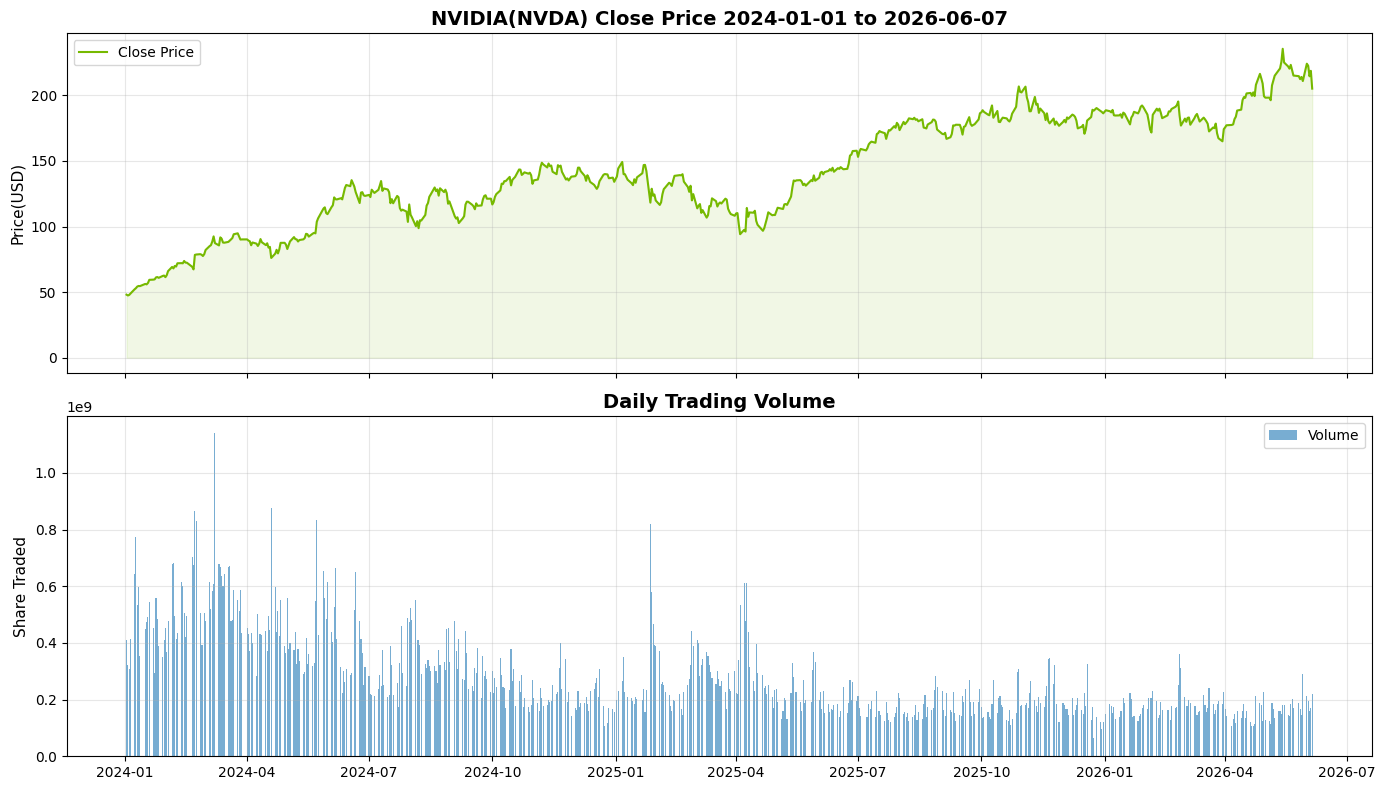

In [0]:
# Quick Pie Chart

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price Chart
axes[0].plot(raw.index, raw['Close'], color='#76b900', linewidth=1.5, label='Close Price')
axes[0].fill_between(raw.index, raw['Close'], color='#76b900', alpha=0.1)
axes[0].set_title(f'NVIDIA(NVDA) Close Price {DATA_START_DATE} to {DATA_END_DATE}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price(USD)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volume Char
axes[1].bar(raw.index, raw['Volume'], color='#1f77b4', alpha=0.6, label='Volume')
axes[1].set_title('Daily Trading Volume', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Share Traded', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [0]:
# Feature Engineering 

def build_features(df):
    """
    Take raw OHLCV dataframe and returns a feature-rich dataframe.
    All indicators are computed using the 'ta' library (Technical Analysis).
    """
    d = df.copy()
    
    # Trend Indicators 
    d['EMA_9'] = ta.trend.ema_indicator(d['Close'], window=9)
    d['EMA_21'] = ta.trend.ema_indicator(d['Close'], window=21)
    d['EMA_50'] = ta.trend.ema_indicator(d['Close'], window=50)
    d['SMA_20'] = ta.trend.sma_indicator(d['Close'], window=20)
    d['SMA_50'] = ta.trend.sma_indicator(d['Close'], window=50)
    
    macd = ta.trend.MACD(d['Close'])
    d['MACD'] = macd.macd()
    d['MACD_Signal'] = macd.macd_signal()
    d['MACD_Hist'] = macd.macd_diff()
    
    d['ADX'] = ta.trend.adx(d['High'], d['Low'], d['Close'], window=14)
    
    # Momentum Indicators
    d['RSI_14'] = ta.momentum.rsi(d['Close'], window=14)
    d['RSI_7'] = ta.momentum.rsi(d['Close'], window=7)
    
    stoch = ta.momentum.StochasticOscillator(d['High'], d['Low'], d['Close'])
    d['STOCH_K'] = stoch.stoch()
    d['STOCH_D'] = stoch.stoch_signal()
    
    d['ROC_5'] = ta.momentum.roc(d['Close'], window=5)
    d['ROC_10'] = ta.momentum.roc(d['Close'], window=10)
    
    # Volatility Indicators 
    bb = ta.volatility.BollingerBands(d['Close'], window=20, window_dev=2)
    d['BB_upper'] = bb.bollinger_hband()
    d['BB_lower'] = bb.bollinger_lband()
    d['BB_middle'] = bb.bollinger_mavg()
    d['BB_width'] = (d['BB_upper'] - d['BB_lower']) / d['BB_middle']
    d['BB_pct'] = bb.bollinger_pband()
    
    d['ATR'] = ta.volatility.average_true_range(d['High'], d['Low'], d['Close'], window=14)
    
    # Volume Indicators
    d['OBV'] = ta.volume.on_balance_volume(d['Close'], d['Volume'])
    d['VWAP'] = ta.volume.volume_weighted_average_price(d['High'], d['Low'], d['Close'], d['Volume'])
    d['Volume_ratio'] = d['Volume'] / d['Volume'].rolling(window=20).mean()
    
    # Price Derived Features
    d['Daily_Return']   = d['Close'].pct_change()
    d['Log_Return']     = np.log(d['Close'] / d['Close'].shift(1))
    d['High_Low_pct']   = (d['High'] - d['Low']) / d['Close']
    d['Open_Close_pct'] = (d['Close'] - d['Open']) / d['Open']
    
    # Lag Features
    for lag in [1, 2, 3, 5, 10]:
        d[f'Close_lag_{lag}']  = d['Close'].shift(lag)
        d[f'Return_lag_{lag}'] = d['Daily_Return'].shift(lag)
        
    # Rolling Statistics
    for window in [5, 10, 20]:
        d[f'Rolling_mean_{window}'] = d['Close'].rolling(window).mean()
        d[f'Rolling_std_{window}']  = d['Close'].rolling(window).std()
        d[f'Rolling_max_{window}']  = d['Close'].rolling(window).max()
        d[f'Rolling_min_{window}']  = d['Close'].rolling(window).min()
        
    # Calendar Features
    d['Day_of_week']     = d.index.dayofweek
    d['Month']           = d.index.month
    d['Quarter']         = d.index.quarter
    d['Price_vs_EMA50']  = (d['Close'] - d['EMA_50']) / d['EMA_50']
    d['Price_vs_SMA20']  = (d['Close'] - d['SMA_20']) / d['SMA_20']
    
    ALL_MODEL_FEATURES = [c for c in d.columns if c not in ['Open','High','Low','Close','Volume']]
    d.dropna(inplace=True)
    df = d

    return d

# Apply Feature Engineering 
df = build_features(raw)

df.dropna(inplace=True)
ALL_MODEL_FEATURES = [col for col in df.columns if col != 'Close']

print(f'Feature Engineering Complete')
print(f'Dataset Shape: {df.shape} ({df.shape[1]} features, {df.shape[0]} trading days)')
print(f'Date range after dropna: {df.index[0].date()} to {df.index[-1].date()}')

Feature Engineering Complete
Dataset Shape: (560, 60) (60 features, 560 trading days)
Date range after dropna: 2024-03-13 to 2026-06-05


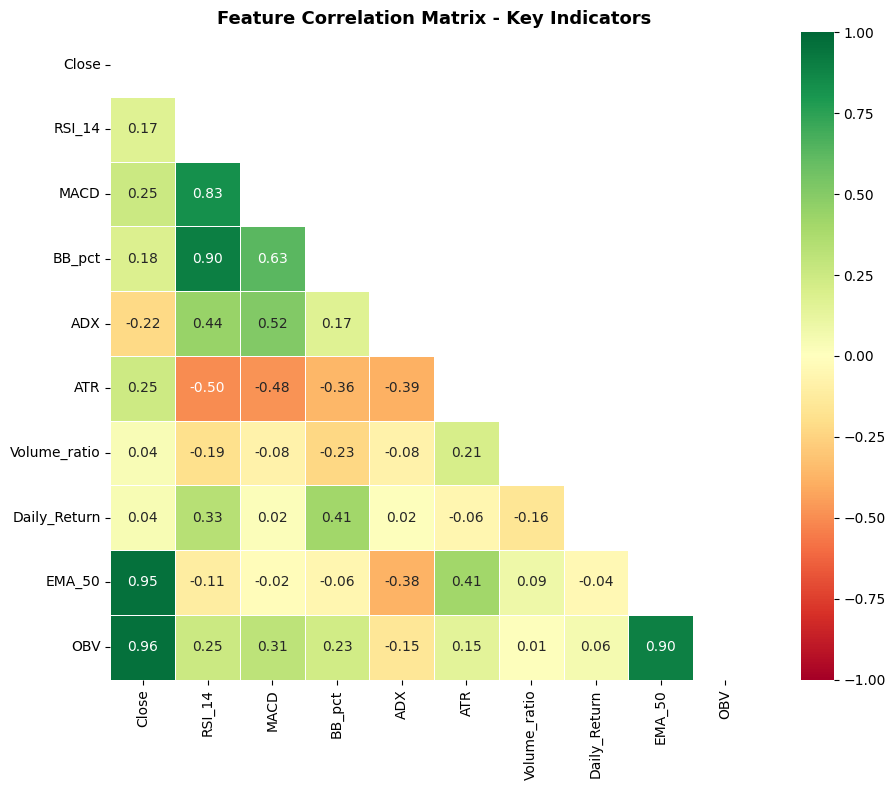

In [0]:
# Correlation Heat Map

key_features = ['Close', 'RSI_14', 'MACD', 'BB_pct', 'ADX', 'ATR', 'Volume_ratio', 'Daily_Return', 'EMA_50', 'OBV']

corr = df[key_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', annot=True, fmt='.2f', square=True, vmin = -1, vmax = 1, linewidths=.5)


plt.title('Feature Correlation Matrix - Key Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# FinBERT Sentiment Analysis
---

In [0]:
# FinBERT News Sentiment

if not DOWNLOAD_LIVE:
    FROZEN_SENTIMENT = -0.1824   
    df['Sentiment'] = FROZEN_SENTIMENT
    mean_sentiment = FROZEN_SENTIMENT
    if 'Sentiment' not in ALL_MODEL_FEATURES:
        ALL_MODEL_FEATURES.append('Sentiment')
    print(f'Using FROZEN sentiment: {mean_sentiment:+.4f}')
else:
    print('Loading FinBERT model (first run downloads ~400MB)...')

# Load FinBERT pipeline explicitly using the transformers library
finbert = pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    truncation=True,
    max_length=512
)

print('FinBERT loaded ✓')

# Fetch NVIDIA news from Yahoo Finance
nvda_ticker = yf.Ticker(TICKER)
news_raw = nvda_ticker.news
print(f'Found {len(news_raw)} news articles')

news_data = []
for article in news_raw:
    content = article.get('content', {})
    title = content.get('title', '') or article.get('title', '')
    pub_time = content.get('pubDate', '') or article.get('providerPublishTime', '')
    
    if pub_time:
        if isinstance(pub_time, (int, float)):
            # Convert Unix timestamp safely to datetime date
            date_obj = datetime.datetime.fromtimestamp(pub_time).date()
        else:
            try:
                date_obj = pd.to_datetime(pub_time).date()
            except:
                date_obj = datetime.date.today()
    else:
        date_obj = datetime.date.today()

    if title:
        news_data.append({'title': title, 'date': pd.to_datetime(date_obj)})

news_df = pd.DataFrame(news_data)
print(f'Extracted {len(news_df)} articles with titles')

if len(news_df) > 0:
    print('\nSample headlines:')
    for h in news_df['title'].head(5):
        print(f'  • {h[:100]}')

Using FROZEN sentiment: -0.1824


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded ✓
Found 10 news articles
Extracted 10 articles with titles

Sample headlines:
  • AI stock mania is taking over the markets in 2026
  • I'm Calling It: UPS Is a Buy Before July 15
  • SK Hynix announces multi-year tech deal with Nvidia for AI factories
  • 3 High-Growth Artificial Intelligence (AI) Stocks to Buy With $5,000 Right Now
  • Want Nothing to Do With SpaceX? Buy This Ultra-Low-Cost Dividend Growth ETF in June.


In [0]:
# Score Headline with FinBERT

def score_sentiment(text):
    """
    Returns a single sentiment score:
    +1.0 = strongly positive, 0.0 = neutral, -1.0 = strongly negative
    Updated with string cleaning to prevent FinBERT from missing sentiment.
    """
    try:
        cleaned_text = str(text).lower().strip()
        
        result = finbert(cleaned_text[:512])[0]  
        label = result['label'].lower()
        score = result['score'] 
        
        if label == 'positive':
            return score       
        elif label == 'negative':
            return -score      
        else:
            return 0.0         
    except Exception as e:
        return 0.0
    
if len(news_df) > 0:
    print('Scoring headlines with FinBERT...')
    news_df['sentiment_score'] = news_df['title'].apply(score_sentiment)
    
    print('\nSample sentiment scores:')
    for _, row in news_df.head(8).iterrows():
        score = row['sentiment_score']
        icon = '🟢' if score > 0.1 else '🔴' if score < -0.1 else '⚪'
        print(f'{icon} {score:+.3f}  |  {row["title"][:80]}')

    daily_sentiment = news_df.groupby('date')['sentiment_score'].mean().to_frame()
    daily_sentiment.columns = ['Sentiment']
    
    if 'Sentiment' in df.columns:
        df.drop(columns=['Sentiment'], inplace=True)
    
    df = df.join(daily_sentiment, how='left')
    df['Sentiment'] = df['Sentiment'].fillna(0.0)
    
    mean_sentiment = news_df['sentiment_score'].mean()
    print(f'\n📊 Mean sentiment score: {mean_sentiment:+.4f}')
    print(f'   Interpretation: {"BULLISH 📈" if mean_sentiment > 0.1 else "BEARISH 📉" if mean_sentiment < -0.1 else "NEUTRAL ➡️"}')

else:
    print('No news data — using neutral sentiment fallback (0.0)')
    if 'Sentiment' not in df.columns:
        df['Sentiment'] = 0.0
    mean_sentiment = 0.0

if 'Sentiment' not in ALL_MODEL_FEATURES:
    ALL_MODEL_FEATURES.append('Sentiment')

print(f'\nSentiment feature added to dataset ✓ value = {mean_sentiment:.4f}')
print(f'Current updated feature count: {len(ALL_MODEL_FEATURES)} features tracked.')

Scoring headlines with FinBERT...

Sample sentiment scores:
⚪ +0.000  |  AI stock mania is taking over the markets in 2026
⚪ +0.000  |  I'm Calling It: UPS Is a Buy Before July 15
🟢 +0.609  |  SK Hynix announces multi-year tech deal with Nvidia for AI factories
⚪ +0.000  |  3 High-Growth Artificial Intelligence (AI) Stocks to Buy With $5,000 Right Now
⚪ +0.000  |  Want Nothing to Do With SpaceX? Buy This Ultra-Low-Cost Dividend Growth ETF in J
⚪ +0.000  |  South Korea's Naver to build gigawatt-scale AI factories using Nvidia technology
⚪ +0.000  |  Marvell leads chip wreck unseen since the pandemic
⚪ +0.000  |  Got $1,000? Here's the Tech Stock I Think Has the Best Risk-Reward Setup in the 

📊 Mean sentiment score: +0.0609
   Interpretation: NEUTRAL ➡️

Sentiment feature added to dataset ✓ value = 0.0609
Current updated feature count: 60 features tracked.


---
# LightGBM Model
---
**Why LightGBM for stock prediction?**
- Handles tabular features extremely well
- Doesn't need data normalization
- Captures non-linear relationship between indicators
- Fast training - we can tune 100+ parameters in minutes
---

In [0]:
# Prepare data for tree models

EXCLUDE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'Target_NextReturn']
BASE_FEATURES = [c for c in df.columns if c not in EXCLUDE_COLS]

lookback_df = df[BASE_FEATURES].copy()
lags = [1, 2, 3, 4]  # Capture a full trading week of history per row

for lag in lags:
    lagged_features = df[BASE_FEATURES].shift(lag)
    lagged_features.columns = [f"{col}_StepLag_{lag}" for col in BASE_FEATURES]
    lookback_df = lookback_df.join(lagged_features)

lookback_df['Target_NextReturn'] = df['Close'].pct_change().shift(-1)
lookback_df['Actual_Close'] = df['Close']

# Separate the last row (for forecasting anchor) before dropping NaNs
forecast_anchor = lookback_df.iloc[[-1]].copy()   # June 5, $205.10

# Drop NaNs only from training rows (excludes last row anyway since target=NaN)
lookback_df.dropna(inplace=True)

# Add the anchor back — it has NaN target but valid features
lookback_df = pd.concat([lookback_df, forecast_anchor])

# ─────────────────────────────────────────────────────────────

FINAL_FEATURE_COLS = [c for c in lookback_df.columns 
                      if c not in ['Target_NextReturn', 'Actual_Close']]

print(f'Enhanced Feature Count (with structural lags): {len(FINAL_FEATURE_COLS)}')

# Training uses only rows with valid targets
train_test_df = lookback_df.dropna(subset=['Target_NextReturn'])
TRAIN_CUTOFF = int(len(train_test_df) * 0.85)

X_all = train_test_df[FINAL_FEATURE_COLS].values
y_all = train_test_df['Target_NextReturn'].values
close_all = train_test_df['Actual_Close'].values

X_train = X_all[:TRAIN_CUTOFF]
y_train = y_all[:TRAIN_CUTOFF]
X_test  = X_all[TRAIN_CUTOFF:]
y_test  = y_all[TRAIN_CUTOFF:]
close_test = close_all[TRAIN_CUTOFF:]

print(f'Training on stationary returns: {len(X_train)} samples')
print(f'Testing on stationary returns:  {len(X_test)} samples')
print(f'Forecast anchor (last row): {lookback_df.index[-1].date()} @ ${lookback_df["Actual_Close"].iloc[-1]:.2f}')

Enhanced Feature Count (with structural lags): 280
Training on stationary returns: 471 samples
Testing on stationary returns:  84 samples
Forecast anchor (last row): 2026-06-05 @ $205.10


In [0]:
# LightGBM Hyperparameter Tuning

optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'mae',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'lambda_l1'        : trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2'        : trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'n_estimators'     : 500,
        'random_state'     : RANDOM_SEED,
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    mae_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val   = X_train[val_idx]
        y_fold_val   = y_train[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        preds = model.predict(X_fold_val)
        mae_scores.append(mean_absolute_error(y_fold_val, preds))
    
    return np.mean(mae_scores)

print('Tuning LightGBM on Returns with Optuna (50 trials)...')
lgb_study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=50)

print(f'\n✓ Best LightGBM Return MAE: {lgb_study.best_value:.6f} ({lgb_study.best_value*100:.3f}% avg return error)')
print(f'Best params: {lgb_study.best_params}')

Tuning LightGBM on Returns with Optuna (50 trials)...

✓ Best LightGBM Return MAE: 0.021933 (2.193% avg return error)
Best params: {'num_leaves': 122, 'learning_rate': 0.09922042977743961, 'feature_fraction': 0.9949371202544097, 'bagging_fraction': 0.7601333260523094, 'bagging_freq': 4, 'min_child_samples': 6, 'lambda_l1': 0.0007126913292289021, 'lambda_l2': 0.00017771318707157383}



LightGBM Test Performance (Stationary Return Basis):
  MAE  = $3.7962  (reconstructed average error in true USD)
  RMSE = $4.9563
  R²   = 0.9145


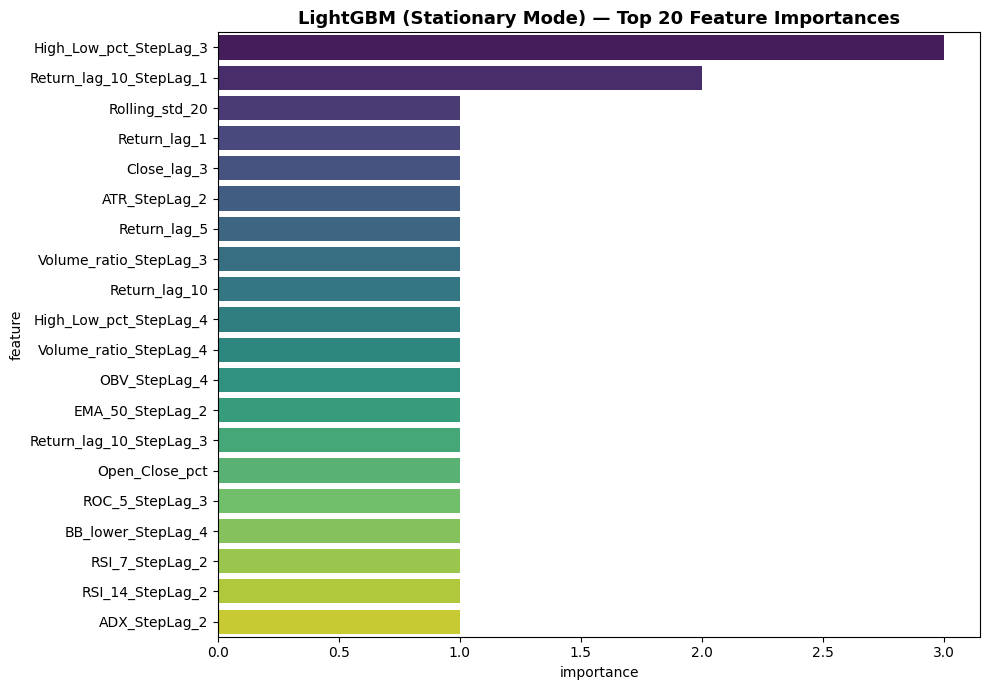

In [0]:
# Train LightGBM Model

lgb_best_params = {
    **lgb_study.best_params,
    'objective'    : 'regression',
    'metric'       : 'mae',
    'verbosity'    : -1,
    'n_estimators' : 1000,
    'random_state' : RANDOM_SEED,
}
lgb_best_params.pop('seed', None)

lgb_model = lgb.LGBMRegressor(**lgb_best_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False), 
        lgb.log_evaluation(period=200)
    ]
)

pred_returns = lgb_model.predict(X_test)

# Formulate: Predicted_Close = True_Prior_Close * (1 + Predicted_Percentage_Return)
lgb_test_preds = close_test * (1 + pred_returns)

# Ground-truth USD next-day targets are reconstructed by checking what the return actually yielded
y_test_real_usd = close_test * (1 + y_test)

# 4. Standardized Evaluation Metrics in true dollar values
lgb_mae  = mean_absolute_error(y_test_real_usd, lgb_test_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test_real_usd, lgb_test_preds))
lgb_r2   = r2_score(y_test_real_usd, lgb_test_preds)

print(f'\nLightGBM Test Performance (Stationary Return Basis):')
print(f'  MAE  = ${lgb_mae:.4f}  (reconstructed average error in true USD)')
print(f'  RMSE = ${lgb_rmse:.4f}')
print(f'  R²   = {lgb_r2:.4f}')

# Plot feature importance using our upgraded lag feature array labels
feat_imp = pd.DataFrame({
    'feature'   : FINAL_FEATURE_COLS,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('LightGBM (Stationary Mode) — Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# XGBoost Model
---

In [0]:
# XGBoost Hyperparameter Tuning 

optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'objective'        : 'reg:squarederror',
        'eval_metric'      : 'mae',
        'n_estimators'     : 500,
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'random_state'     : RANDOM_SEED,
        'verbosity'        : 0,
        'early_stopping_rounds': 50  
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    mae_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val   = X_train[val_idx]
        y_fold_val   = y_train[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )
        preds = model.predict(X_fold_val)
        mae_scores.append(mean_absolute_error(y_fold_val, preds))
    
    return np.mean(mae_scores)


print('Tuning XGBoost on Returns with Optuna (50 trials)...')
xgb_study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=50)

print(f'\n✓ Best XGBoost Return MAE: {xgb_study.best_value:.6f} ({xgb_study.best_value*100:.3f}% avg return error)')
print(f'Best params: {xgb_study.best_params}')

Tuning XGBoost on Returns with Optuna (50 trials)...

✓ Best XGBoost Return MAE: 0.021800 (2.180% avg return error)
Best params: {'max_depth': 3, 'learning_rate': 0.0839587612140778, 'subsample': 0.5887663591658135, 'colsample_bytree': 0.6365931207352723, 'reg_alpha': 1.545145140328815e-08, 'reg_lambda': 1.0936304934860763, 'min_child_weight': 3}


In [0]:
# Train XGBoost Model

xgb_best_params = {
    **xgb_study.best_params,
    'objective'    : 'reg:squarederror',
    'n_estimators' : 1000,
    'random_state' : RANDOM_SEED,
    'verbosity'    : 0,
    'early_stopping_rounds': 50,
    'tree_method'  : 'hist', 
    'n_jobs'       : -1,      
}

xgb_model = xgb.XGBRegressor(**xgb_best_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_pred_returns = xgb_model.predict(X_test)

xgb_test_preds = close_test * (1 + xgb_pred_returns)

y_test_real_usd = close_test * (1 + y_test)

xgb_mae  = mean_absolute_error(y_test_real_usd, xgb_test_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test_real_usd, xgb_test_preds))
xgb_r2   = r2_score(y_test_real_usd, xgb_test_preds)

print(f'\nXGBoost Test Performance (Stationary Return Basis):')
print(f'  MAE  = ${xgb_mae:.4f}  (reconstructed average error in true USD)')
print(f'  RMSE = ${xgb_rmse:.4f}')
print(f'  R²   = {xgb_r2:.4f}')

[0]	validation_0-rmse:0.02555
[50]	validation_0-rmse:0.02666

XGBoost Test Performance (Stationary Return Basis):
  MAE  = $3.8351  (reconstructed average error in true USD)
  RMSE = $5.0252
  R²   = 0.9121


---
# LSTM with Attention
---
**How LSTM Attention works**

- Regular neural networks teach each output independently 
- LSTM have a 'memory cell' that can remember information from many step back
- It learns what to remember, what to forgot and what to output at each step
- Attention mechanism on top: tells the model which past time steps are more important for making current prediction
---

In [0]:
# Preparing Sequences for LSTM

LOOKBACK = 30

macd_signal_col = [c for c in lookback_df.columns if 'macd' in c.lower() and 'sign' in c.lower()]
macd_signal_name = macd_signal_col[0] if len(macd_signal_col) > 0 else 'MACD_Signal'

LSTM_FEATURES = [
    'Actual_Close', 'Volume', 'RSI_14', 'MACD', macd_signal_name,
    'BB_pct', 'BB_width', 'ATR', 'EMA_9', 'EMA_21',
    'Daily_Return', 'Volume_ratio', 'High_Low_pct', 'ADX', 'Sentiment'
]
LSTM_FEATURES = [c for c in LSTM_FEATURES if c in lookback_df.columns]
target_col = 'Target_NextReturn'

print(f"Features tracked count: {len(LSTM_FEATURES)}")
print(f"Anchor row (last): {lookback_df.index[-1].date()} @ ${lookback_df['Actual_Close'].iloc[-1]:.2f}")

# Use only rows that have valid feature values (all rows including anchor)
# but exclude anchor from target-based split since target is NaN there
X_raw = lookback_df[LSTM_FEATURES].values        # includes anchor row
y_raw_full = lookback_df[target_col].values      # last value is NaN

# Fit scaler on ALL feature rows (including anchor) so June 5 is in distribution
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# For scaler_y, fit only on non-NaN target rows
valid_mask = ~np.isnan(y_raw_full)
y_raw_valid = y_raw_full[valid_mask].reshape(-1, 1)

scaler_X.fit(X_raw)                    # fit on all rows including anchor
scaler_y.fit(y_raw_valid)              # fit on valid targets only

# Scale everything
X_scaled = scaler_X.transform(X_raw)

# For sequences: use only rows with valid targets (exclude anchor for training)
X_raw_train = lookback_df[valid_mask][LSTM_FEATURES].values
y_raw_train = y_raw_valid

X_scaled_train = scaler_X.transform(X_raw_train)
y_scaled_train = scaler_y.transform(y_raw_train)

# Train/test split on valid rows only
split_idx = int(len(X_scaled_train) * 0.85)

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback : i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled_train, y_scaled_train, LOOKBACK)

sequence_split = split_idx - LOOKBACK
X_train_seq = X_seq[:sequence_split]
X_test_seq  = X_seq[sequence_split:]
y_train_seq = y_seq[:sequence_split]
y_test_seq  = y_seq[sequence_split:]

# Close prices for reconstruction (aligned to test set)
close_test_lstm = lookback_df[valid_mask]['Actual_Close'].values[split_idx:]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t = torch.FloatTensor(X_train_seq).to(device)
y_train_t = torch.FloatTensor(y_train_seq).to(device)
X_test_t  = torch.FloatTensor(X_test_seq).to(device)
y_test_t  = torch.FloatTensor(y_test_seq).to(device)

train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)

print(f'Sequence shape: {X_seq.shape}')
print(f'Train sequences: {len(X_train_seq)}  |  Test sequences: {len(X_test_seq)}')
print(f'Scaler fitted including anchor row: ✓')
print(f'Anchor close (forecast start): ${lookback_df["Actual_Close"].iloc[-1]:.2f}')

Features tracked count: 14
Anchor row (last): 2026-06-05 @ $205.10
Sequence shape: (525, 30, 14)
Train sequences: 441  |  Test sequences: 84
Scaler fitted including anchor row: ✓
Anchor close (forecast start): $205.10


In [0]:
# Define LSTM with attention architecture

class Attention(nn.Module):
    """
    Bahdanau-style Attention mechanism.
    
    What it does:
    - Takes all hidden states from the LSTM (one per time step)
    - Learns a 'score' for each time step: how important is this day?
    - Converts scores to weights using softmax (weights sum to 1.0)
    - Produces a weighted average of all hidden states
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def forward(self, lstm_output):
        scores = self.attention(lstm_output)           
        weights = torch.softmax(scores, dim=1)         
        
        context = torch.sum(weights * lstm_output, dim=1) # Shape: (batch, hidden_size)
        return context, weights


class LSTMWithAttention(nn.Module):
    """
    Full Architecture:
    Input → LSTM (2 layers) → Dropout → Attention → Fully Connected → Output
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0, 
            batch_first=True     
        )
        
        self.attention  = Attention(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        
        lstm_out, _ = self.lstm(x)                       
        context, attn_weights = self.attention(lstm_out)  
        context = self.dropout(context)
        out = self.fc(context)                            
        return out, attn_weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lstm_model = LSTMWithAttention(
        input_size=len(LSTM_FEATURES),
        hidden_size=128, num_layers=2, dropout=0.3
    ).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'LSTM model ready. Trainable parameters: {total_params:,}')

LSTM model ready. Trainable parameters: 214,274


In [0]:
# Train LSTM Model

EPOCHS = 100
LR     = 0.001

lstm_model = LSTMWithAttention(
    input_size=len(LSTM_FEATURES),
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion  = nn.HuberLoss()

train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_state       = None
patience_counter = 0
EARLY_STOP_PATIENCE = 20

for epoch in range(EPOCHS):

    lstm_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds, _ = lstm_model(X_batch)
        loss = criterion(preds.squeeze(1), y_batch.squeeze(1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    lstm_model.eval()
    with torch.no_grad():
        val_preds, _ = lstm_model(X_test_t)
        val_loss = criterion(val_preds.squeeze(1), y_test_t.squeeze(1)).item()

    # Guard against NaN — skip update if NaN appears
    if np.isnan(val_loss) or np.isnan(avg_train_loss):
        print(f'Epoch [{epoch+1:3d}] NaN detected — skipping weight update')
        continue

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

    if (epoch + 1) % 10 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:3d}/{EPOCHS}]  Train: {avg_train_loss:.6f}  Val: {val_loss:.6f}  LR: {lr_now:.6f}')

# Restore best weights
if best_state is not None:
    lstm_model.load_state_dict(best_state)
    print(f'\n✓ Best val loss restored: {best_val_loss:.6f}')
else:
    print('\n⚠ No best state — model used as-is. Check data for NaN.')

Epoch [ 10/100]  Train: 0.004722  Val: 0.002935  LR: 0.001000
Epoch [ 20/100]  Train: 0.004994  Val: 0.002632  LR: 0.001000
Epoch [ 30/100]  Train: 0.004224  Val: 0.002515  LR: 0.001000
Epoch [ 40/100]  Train: 0.004129  Val: 0.002642  LR: 0.001000
Epoch [ 50/100]  Train: 0.004391  Val: 0.002574  LR: 0.000500
Early stopping at epoch 51

✓ Best val loss restored: 0.002497


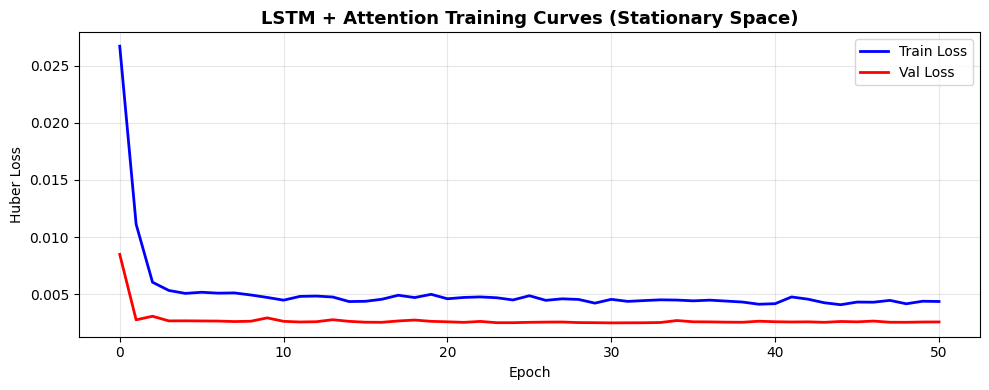

LSTM+Attention Test Performance (Stationary Return Basis):
  MAE  = $3.7810  (reconstructed average error in true USD)
  RMSE = $4.9695
  R²   = 0.9140


In [0]:
# Evaluate LSTM

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='blue', lw=2)
plt.plot(val_losses,   label='Val Loss',   color='red', lw=2)
plt.title('LSTM + Attention Training Curves (Stationary Space)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_curve.png', dpi=120)
plt.show()

lstm_model.eval()
with torch.no_grad():
    lstm_test_scaled, _ = lstm_model(X_test_t)
    lstm_test_scaled = lstm_test_scaled.cpu().numpy()

lstm_pred_returns = scaler_y.inverse_transform(lstm_test_scaled).flatten()
lstm_actual_returns = scaler_y.inverse_transform(y_test_seq).flatten()

close_test_aligned = close_test_lstm[-len(lstm_pred_returns):]

lstm_test_preds = close_test_aligned * (1 + lstm_pred_returns)
lstm_test_actual = close_test_aligned * (1 + lstm_actual_returns)

lstm_mae  = mean_absolute_error(lstm_test_actual, lstm_test_preds)
lstm_rmse = np.sqrt(mean_squared_error(lstm_test_actual, lstm_test_preds))
lstm_r2   = r2_score(lstm_test_actual, lstm_test_preds)

print(f'LSTM+Attention Test Performance (Stationary Return Basis):')
print(f'  MAE  = ${lstm_mae:.4f}  (reconstructed average error in true USD)')
print(f'  RMSE = ${lstm_rmse:.4f}')
print(f'  R²   = {lstm_r2:.4f}')

---
# Temporal Fusion Transformer (TFT)
---
**Why TFT?**

- Adaptive Feature Selection (The Noise Filter)
- Multi-Head Self-Attention (Long-Range Memory)
- Native Handling of Multi-Horizon Data
- High Interpretability (Built-In Feature Importance)
---

In [0]:
# Prepare data architecture for TFT

class UpgradedVariableSelectionNetwork(nn.Module):
    """Weighs features dynamically per timestep with LayerNorm/Dropout stability."""
    def __init__(self, num_features, d_model, dropout=0.1):
        super().__init__()
        self.feature_mappings = nn.ModuleList([nn.Linear(1, d_model) for _ in range(num_features)])
        self.flatten_weights  = nn.Linear(num_features * d_model, num_features)
        self.layer_norm       = nn.LayerNorm(d_model)
        self.dropout          = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch, seq_len, num_features)
        batch_size, seq_len, num_features = x.shape
        
        mapped = []
        for i in range(num_features):
            feat = x[:, :, i:i+1] # Isolate channel
            proj = self.feature_mappings[i](feat) # Project to d_model space
            mapped.append(proj.unsqueeze(-1)) # Shape: (batch, seq_len, d_model, 1)
            
        mapped = torch.cat(mapped, dim=-1) # Shape: (batch, seq_len, d_model, num_features)
        flat_mapped = mapped.permute(0, 1, 3, 2).reshape(batch_size, seq_len, -1)
        
        # Softmax feature importance generation
        weights = torch.softmax(self.flatten_weights(flat_mapped), dim=-1).unsqueeze(2)
        
        # Dynamic element-wise weighted summation
        vsn_out = torch.sum(weights * mapped, dim=-1) 
        return self.layer_norm(self.dropout(vsn_out))


class EnhancedTFTLite(nn.Module):
    """Deep structural TFT block utilizing wider feature projections for time-series."""
    def __init__(self, num_features, seq_len, d_model=128, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.vsn = UpgradedVariableSelectionNetwork(num_features, d_model, dropout)
        
        # Robust Transformer Encoder with 128 d_model dimensionality
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, # Expanded projection fields
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Multi-stage decoder projection layer
        self.decoder = nn.Sequential(
            nn.Linear(d_model * seq_len, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        vsn_out = self.vsn(x)
        att_out = self.transformer(vsn_out)
        flat = att_out.reshape(att_out.size(0), -1)
        return self.decoder(flat)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_features_in = X_train_seq.shape[2] # 14 features
lookback_len = X_train_seq.shape[1]    # 30 timesteps

enhanced_tft = EnhancedTFTLite(
    num_features=num_features_in,
    seq_len=lookback_len,
    d_model=128,  # Increased representation capacity
    nhead=4,
    num_layers=2,
    dropout=0.2
).to(device)

tft_params = sum(p.numel() for p in enhanced_tft.parameters() if p.requires_grad)
print("Enhanced TFT Classes Defined & Initialized ✓")
print(f"Total Trainable Structural Parameters: {tft_params:,}")

Enhanced TFT Classes Defined & Initialized ✓
Total Trainable Structural Parameters: 671,375


In [0]:
# Train TFT

tft_criterion = nn.HuberLoss(delta=1.0) # Switched from MSE to Huber Loss for noise dampening
tft_optimizer = torch.optim.AdamW(enhanced_tft.parameters(), lr=0.0005, weight_decay=1e-3) # Tighter LR
tft_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(tft_optimizer, patience=5, factor=0.5)

tft_epochs = 50
print("Training Enhanced Temporal Fusion Transformer...")

for epoch in range(tft_epochs):
    enhanced_tft.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        tft_optimizer.zero_grad()
        
        predictions = enhanced_tft(batch_X)
        loss = tft_criterion(predictions, batch_y)
        
        loss.backward()
        # Gradient clipping to shield transformer from micro-volatility crashes
        torch.nn.utils.clip_grad_norm_(enhanced_tft.parameters(), max_norm=1.0) 
        
        tft_optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    tft_scheduler.step(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:2d}/{tft_epochs}] | Stable Loss: {avg_loss:.6f}")

enhanced_tft.eval()
with torch.no_grad():
    tft_test_scaled = enhanced_tft(X_test_t).cpu().numpy()

# Reverse Transform: Scaled Decimals -> Percentage Returns
tft_pred_returns = scaler_y.inverse_transform(tft_test_scaled).flatten()
tft_actual_returns = scaler_y.inverse_transform(y_test_seq).flatten()

# Extract and align true dollar bases from lookback_df context tracking
close_test_aligned = close_test_lstm[-len(tft_pred_returns):]

# Reverse Transform: Percentage Returns -> True USD Price Values
tft_test_preds = close_test_aligned * (1 + tft_pred_returns)
tft_test_actual = close_test_aligned * (1 + tft_actual_returns)

# Calculate final verified evaluation benchmarks
tft_mae  = mean_absolute_error(tft_test_actual, tft_test_preds)
tft_rmse = np.sqrt(mean_squared_error(tft_test_actual, tft_test_preds))
tft_r2   = r2_score(tft_test_actual, tft_test_preds)

print(f'\nEnhanced TFT Test Performance Evaluation Metrics:')
print(f'  MAE  = ${tft_mae:.4f} (reconstructed average error in true USD)')
print(f'  RMSE = ${tft_rmse:.4f}')
print(f'  R²   = {tft_r2:.4f}')

Training Enhanced Temporal Fusion Transformer...
  Epoch [ 1/50] | Stable Loss: 0.152415
  Epoch [10/50] | Stable Loss: 0.007991
  Epoch [20/50] | Stable Loss: 0.007310
  Epoch [30/50] | Stable Loss: 0.007938
  Epoch [40/50] | Stable Loss: 0.006699
  Epoch [50/50] | Stable Loss: 0.006808

Enhanced TFT Test Performance Evaluation Metrics:
  MAE  = $3.8111 (reconstructed average error in true USD)
  RMSE = $5.0027
  R²   = 0.9128


---
# Model Comparison & Ensemble
---

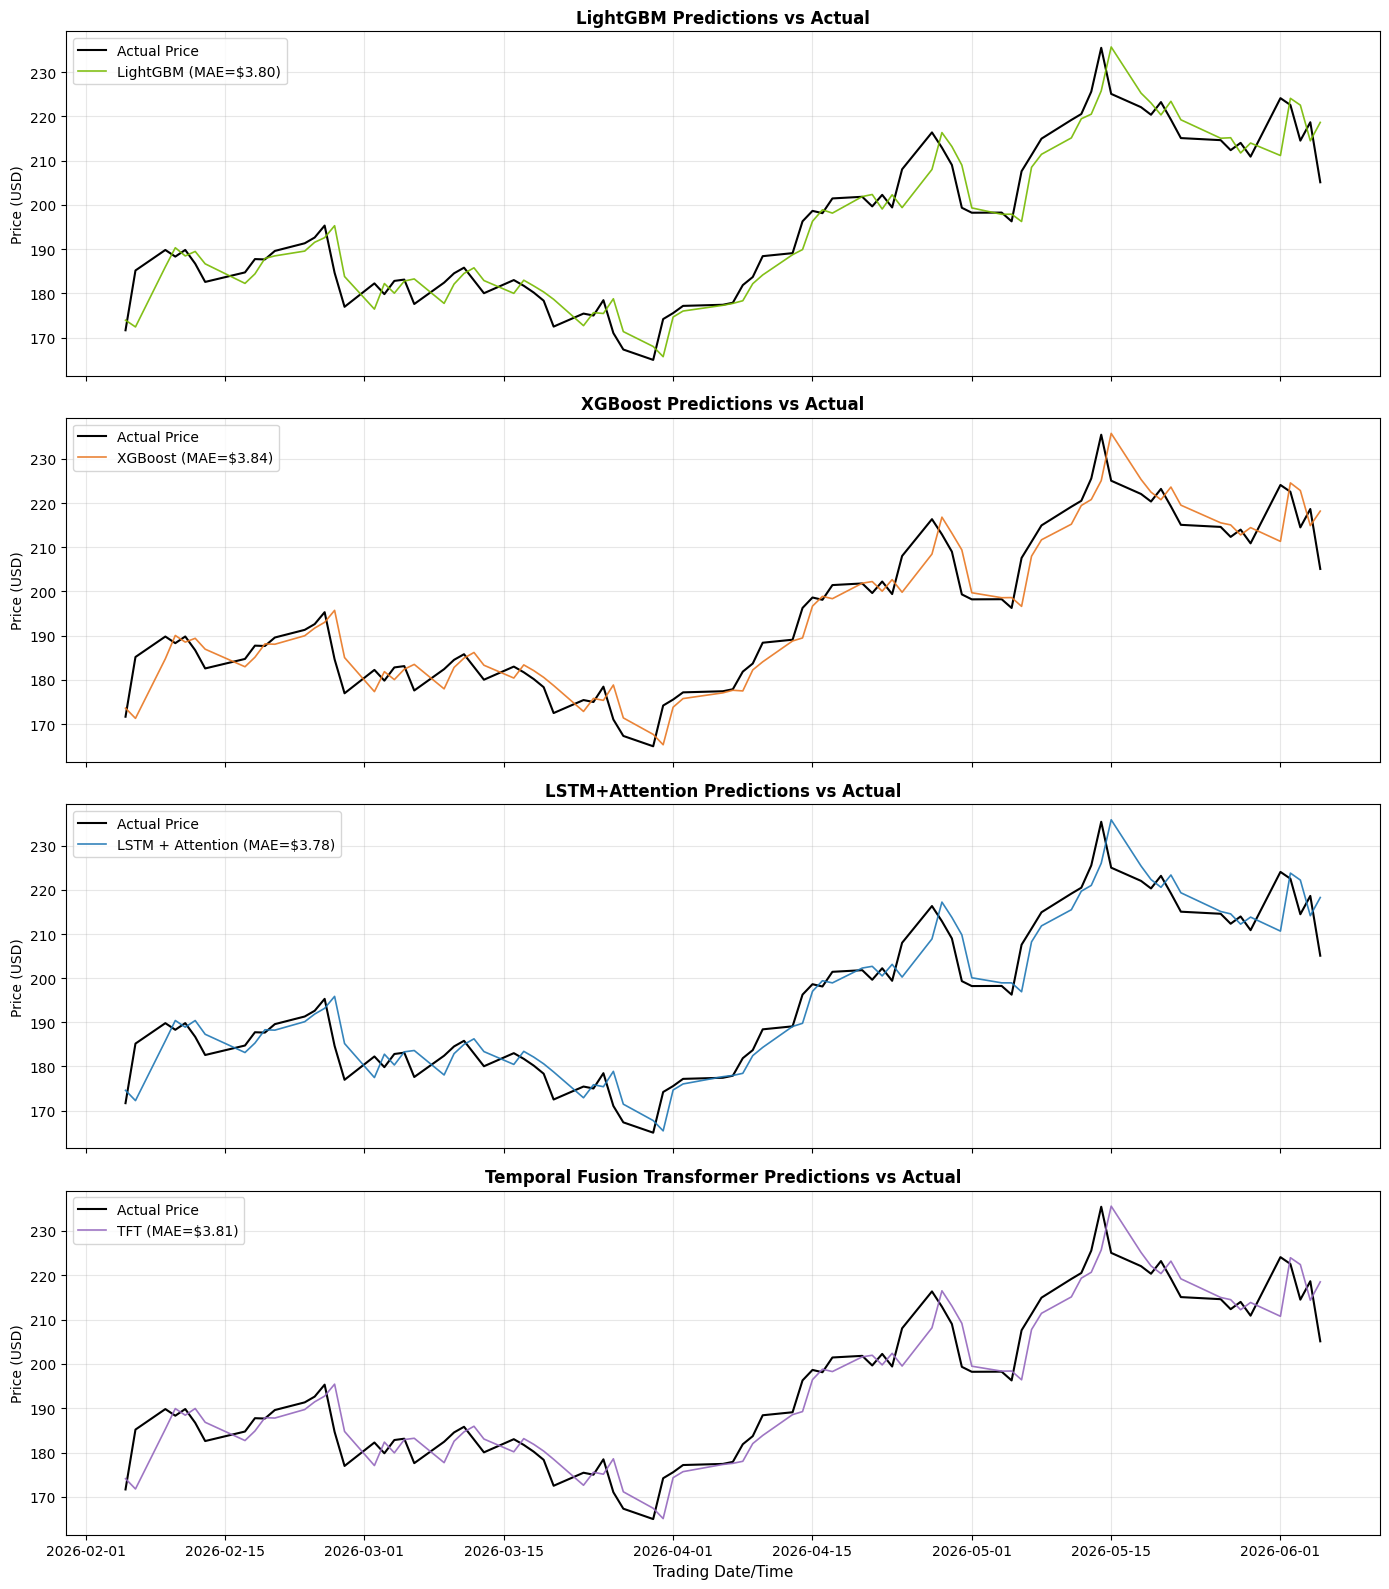


📊 Model Performance Master Summary Table:
----------------------------------------------------------------------
  LightGBM      | MAE = $3.7962  | RMSE = $4.9563  | R² = 0.9145
  Enhanced TFT  | MAE = $3.8111  | RMSE = $5.0027  | R² = 0.9128
  XGBoost       | MAE = $3.8351  | RMSE = $5.0252  | R² = 0.9121
  LSTM + Attn   | MAE = $3.7810  | RMSE = $4.9695  | R² = 0.9140
----------------------------------------------------------------------


In [0]:
# Model Comparison Chart

dates_clean = lookback_df.index

# Align test dates exactly to the out-of-sample window matching the predictions length
# Slicing from the end ensures absolute alignment for deep learning and tree models alike
min_preds_len = min(len(lgb_test_preds), len(xgb_test_preds), len(lstm_test_preds), len(tft_test_preds))
test_dates_aligned = dates_clean[-min_preds_len:]

# Isolate matching target sequences
lgb_plot_preds  = lgb_test_preds[-min_preds_len:]
xgb_plot_preds  = xgb_test_preds[-min_preds_len:]
lstm_plot_preds = lstm_test_preds[-min_preds_len:]
tft_plot_preds  = tft_test_preds[-min_preds_len:]
actual_prices   = tft_test_actual[-min_preds_len:] # True historical price paths

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# LightGBM Plotting
axes[0].plot(test_dates_aligned, actual_prices, label='Actual Price', color='black', linewidth=1.5)
axes[0].plot(test_dates_aligned, lgb_plot_preds, label=f'LightGBM (MAE=${lgb_mae:.2f})', color='#76b900', linewidth=1.2, alpha=0.9)
axes[0].set_title('LightGBM Predictions vs Actual', fontweight='bold', fontsize=12)
axes[0].legend(loc='upper left'); axes[0].grid(True, alpha=0.3)

# XGBoost Plotting
axes[1].plot(test_dates_aligned, actual_prices, label='Actual Price', color='black', linewidth=1.5)
axes[1].plot(test_dates_aligned, xgb_plot_preds, label=f'XGBoost (MAE=${xgb_mae:.2f})', color='#e87722', linewidth=1.2, alpha=0.9)
axes[1].set_title('XGBoost Predictions vs Actual', fontweight='bold', fontsize=12)
axes[1].legend(loc='upper left'); axes[1].grid(True, alpha=0.3)

# LSTM + Attention Plotting
axes[2].plot(test_dates_aligned, actual_prices, label='Actual Price', color='black', linewidth=1.5)
axes[2].plot(test_dates_aligned, lstm_plot_preds, label=f'LSTM + Attention (MAE=${lstm_mae:.2f})', color='#1f77b4', linewidth=1.2, alpha=0.9)
axes[2].set_title('LSTM+Attention Predictions vs Actual', fontweight='bold', fontsize=12)
axes[2].legend(loc='upper left'); axes[2].grid(True, alpha=0.3)

# Temporal Fusion Transformer (TFT) Plotting
axes[3].plot(test_dates_aligned, actual_prices, label='Actual Price', color='black', linewidth=1.5)
axes[3].plot(test_dates_aligned, tft_plot_preds, label=f'TFT (MAE=${tft_mae:.2f})', color='#9467bd', linewidth=1.2, alpha=0.9)
axes[3].set_title('Temporal Fusion Transformer Predictions vs Actual', fontweight='bold', fontsize=12)
axes[3].legend(loc='upper left'); axes[3].grid(True, alpha=0.3)

# Global axis clean-ups
for ax in axes:
    ax.set_ylabel('Price (USD)', fontsize=10)
plt.xlabel('Trading Date/Time', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📊 Model Performance Master Summary Table:')
print('-' * 70)
print(f'  LightGBM      | MAE = ${lgb_mae:.4f}  | RMSE = ${lgb_rmse:.4f}  | R² = {lgb_r2:.4f}')
print(f'  Enhanced TFT  | MAE = ${tft_mae:.4f}  | RMSE = ${tft_rmse:.4f}  | R² = {tft_r2:.4f}')
print(f'  XGBoost       | MAE = ${xgb_mae:.4f}  | RMSE = ${xgb_rmse:.4f}  | R² = {xgb_r2:.4f}')
print(f'  LSTM + Attn   | MAE = ${lstm_mae:.4f}  | RMSE = ${lstm_rmse:.4f}  | R² = {lstm_r2:.4f}')
print('-' * 70)

In [0]:
# 5 Day Recursive Forecasting

def recursive_forecast_trees(
    lgb_m,
    xgb_m,
    tft_m,                     # kept for compatibility, not used here
    lookback_df_ref,
    final_feature_cols,
    lstm_features,             # kept for compatibility, not used here
    scaler_x_ref,              # kept for compatibility, not used here
    scaler_y_ref,              # kept for compatibility, not used here
    n_steps=5,
    weights=None
):
    """
    Recursive multi-step forecast using LightGBM and XGBoost.

    Assumptions:
    - Models predict next-day return (not price).
    - Actual_Close exists in lookback_df_ref.
    - Daily_Return exists in lookback_df_ref.

    Returns:
        tree_step_results : list of dictionaries
        df_temp           : dataframe including synthetic future rows
    """

    if weights is None:
        weights = [0.30, 0.20, 0.20, 0.30]

    W_lgb, W_xgb, W_lstm, W_tft = weights

    df_temp = lookback_df_ref.copy()
    tree_step_results = []

    for step in range(n_steps):

        last_features = df_temp[final_feature_cols].iloc[-1:].values


        ret_lgb = float(lgb_m.predict(last_features)[0])
        ret_xgb = float(xgb_m.predict(last_features)[0])

        prior_close = float(df_temp["Actual_Close"].iloc[-1])

        pred_lgb_price = prior_close * (1 + ret_lgb)
        pred_xgb_price = prior_close * (1 + ret_xgb)

        tree_weight_sum = W_lgb + W_xgb

        ensemble_ret = (
            (W_lgb / tree_weight_sum) * ret_lgb
            + (W_xgb / tree_weight_sum) * ret_xgb
        )

        ensemble_price = prior_close * (1 + ensemble_ret)

        tree_step_results.append({
            "step": step + 1,
            "prior_close": prior_close,
            "lgb_return": ret_lgb,
            "xgb_return": ret_xgb,
            "ensemble_return": ensemble_ret,
            "lgb_price": pred_lgb_price,
            "xgb_price": pred_xgb_price,
            "ensemble_price": ensemble_price
        })


        new_row = df_temp.iloc[-1:].copy()

        next_date = (
            df_temp.index[-1]
            + pd.tseries.offsets.BusinessDay(1)
        )

        new_row.index = [next_date]

        new_row["Actual_Close"] = ensemble_price
        new_row["Daily_Return"] = ensemble_ret

        if prior_close > 0:
            new_row["Log_Return"] = np.log(
                ensemble_price / prior_close
            )
        else:
            new_row["Log_Return"] = 0


        if "Daily_Return_StepLag_4" in df_temp.columns:
            new_row["Daily_Return_StepLag_4"] = (
                df_temp["Daily_Return_StepLag_3"].iloc[-1]
            )

        if "Daily_Return_StepLag_3" in df_temp.columns:
            new_row["Daily_Return_StepLag_3"] = (
                df_temp["Daily_Return_StepLag_2"].iloc[-1]
            )

        if "Daily_Return_StepLag_2" in df_temp.columns:
            new_row["Daily_Return_StepLag_2"] = (
                df_temp["Daily_Return_StepLag_1"].iloc[-1]
            )

        if "Daily_Return_StepLag_1" in df_temp.columns:
            new_row["Daily_Return_StepLag_1"] = ensemble_ret

        if "Daily_Return_StepLag_1" in df_temp.columns:
            new_row["Daily_Return_StepLag_1"] = ensemble_ret

        df_temp = pd.concat([df_temp, new_row])


        for w in [5, 10, 20]:

            mean_col = f"Rolling_mean_{w}"
            std_col = f"Rolling_std_{w}"

            if mean_col in df_temp.columns:

                recent_closes = (
                    list(df_temp["Actual_Close"].tail(w - 1))
                    + [ensemble_price]
                )

                new_row[mean_col] = np.mean(recent_closes)

                if std_col in df_temp.columns:
                    new_row[std_col] = np.std(
                        recent_closes,
                        ddof=0
                    )

        ema_settings = [
            (9, "EMA_9"),
            (21, "EMA_21"),
            (50, "EMA_50")
        ]

        for span, col in ema_settings:

            if col in df_temp.columns:

                alpha = 2 / (span + 1)

                new_row[col] = (
                    ensemble_price * alpha
                    + df_temp[col].iloc[-1] * (1 - alpha)
                )


        if "Day_of_week" in df_temp.columns:
            new_row["Day_of_week"] = next_date.dayofweek

        if "Month" in df_temp.columns:
            new_row["Month"] = next_date.month

        if "Quarter" in df_temp.columns:
            new_row["Quarter"] = next_date.quarter

        df_temp = pd.concat([df_temp, new_row])

    return tree_step_results, df_temp

In [0]:
# LSTM Forecast

def lstm_recursive_forecast(model, lookback_df_ref, lstm_features,
                             scaler_x_ref, scaler_y_ref, lookback=30, n_steps=5):
    """
    Recursively forecasts using LSTM+Attention.
    Slides the 30-day window forward, updating Close with each prediction.
    """
    model.eval()
    
    available_feats = [f for f in lstm_features if f in lookback_df_ref.columns]
    seed_data   = lookback_df_ref[available_feats].values[-lookback:].copy()
    seed_scaled = scaler_x_ref.transform(seed_data)
    
    forecasts_ret   = []
    forecasts_price = []
    current_window  = seed_scaled.copy()
    prior_close     = lookback_df_ref['Actual_Close'].iloc[-1]
    
    close_idx = available_feats.index('Actual_Close') if 'Actual_Close' in available_feats else 0
    ret_idx   = available_feats.index('Daily_Return') if 'Daily_Return' in available_feats else None
    
    for step in range(n_steps):
        x_input = torch.FloatTensor(current_window).unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred_scaled, _ = model(x_input)
        
        pred_ret   = scaler_y_ref.inverse_transform(pred_scaled.cpu().numpy())[0][0]
        pred_price = prior_close * (1 + pred_ret)
        
        forecasts_ret.append(pred_ret)
        forecasts_price.append(pred_price)
        
        # Build new scaled row
        new_row_original = scaler_x_ref.inverse_transform([current_window[-1]])[0].copy()
        new_row_original[close_idx] = pred_price
        if ret_idx is not None:
            new_row_original[ret_idx] = pred_ret
        
        new_row_scaled = scaler_x_ref.transform([new_row_original])[0]
        current_window = np.vstack([current_window[1:], new_row_scaled])
        prior_close    = pred_price
    
    return forecasts_price, forecasts_ret

In [0]:
# TFT Forecast 

def tft_recursive_forecast(model, lookback_df_ref, lstm_features,
                            scaler_x_ref, scaler_y_ref, lookback=30, n_steps=5):
    """
    TFT uses the same sequence format as LSTM — identical recursive logic.
    """
    model.eval()
    
    available_feats = [f for f in lstm_features if f in lookback_df_ref.columns]
    seed_data   = lookback_df_ref[available_feats].values[-lookback:].copy()
    seed_scaled = scaler_x_ref.transform(seed_data)
    
    forecasts_price = []
    current_window  = seed_scaled.copy()
    prior_close     = lookback_df_ref['Actual_Close'].iloc[-1]
    
    close_idx = available_feats.index('Actual_Close') if 'Actual_Close' in available_feats else 0
    ret_idx   = available_feats.index('Daily_Return') if 'Daily_Return' in available_feats else None
    
    for step in range(n_steps):
        x_input = torch.FloatTensor(current_window).unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred_scaled = model(x_input)
            if isinstance(pred_scaled, tuple):
                pred_scaled = pred_scaled[0]
        
        pred_ret   = scaler_y_ref.inverse_transform(pred_scaled.cpu().numpy())[0][0]
        pred_price = prior_close * (1 + pred_ret)
        
        forecasts_price.append(pred_price)
        
        new_row_original = scaler_x_ref.inverse_transform([current_window[-1]])[0].copy()
        new_row_original[close_idx] = pred_price
        if ret_idx is not None:
            new_row_original[ret_idx] = pred_ret
        
        new_row_scaled = scaler_x_ref.transform([new_row_original])[0]
        current_window = np.vstack([current_window[1:], new_row_scaled])
        prior_close    = pred_price
    
    return forecasts_price

In [0]:
# All Forecasts

print('Running 5-day recursive forecasts for all models...\n')

# Tree models
tree_results, _ = recursive_forecast_trees(
    lgb_model, xgb_model, enhanced_tft,
    lookback_df, FINAL_FEATURE_COLS, LSTM_FEATURES,
    scaler_X, scaler_y,
    n_steps=FORECAST_DAYS,
    weights=ENSEMBLE_WEIGHTS
)

# LSTM
lstm_prices, lstm_rets = lstm_recursive_forecast(
    lstm_model, lookback_df, LSTM_FEATURES,
    scaler_X, scaler_y, LOOKBACK, n_steps=FORECAST_DAYS
)

# TFT
tft_prices = tft_recursive_forecast(
    enhanced_tft, lookback_df, LSTM_FEATURES,
    scaler_X, scaler_y, LOOKBACK, n_steps=FORECAST_DAYS
)

print('✓ All model forecasts complete')
print(f'\nPer-step preview:')
for i in range(FORECAST_DAYS):
    print(f"  Step {i+1}: LGB=${tree_results[i]['lgb_price']:.2f}  "
          f"XGB=${tree_results[i]['xgb_price']:.2f}  "
          f"LSTM=${lstm_prices[i]:.2f}  "
          f"TFT=${tft_prices[i]:.2f}")

Running 5-day recursive forecasts for all models...

✓ All model forecasts complete

Per-step preview:
  Step 1: LGB=$205.06  XGB=$205.36  LSTM=$204.72  TFT=$204.96
  Step 2: LGB=$205.15  XGB=$205.45  LSTM=$204.32  TFT=$204.81
  Step 3: LGB=$205.23  XGB=$205.53  LSTM=$203.91  TFT=$204.64
  Step 4: LGB=$205.32  XGB=$205.61  LSTM=$203.48  TFT=$204.47
  Step 5: LGB=$205.40  XGB=$205.70  LSTM=$203.04  TFT=$204.29


In [0]:
# Final Ensemble Forecast 

W_lgb, W_xgb, W_lstm, W_tft = ENSEMBLE_WEIGHTS

# Forecast dates: next 5 business days after DATA_END_DATE
last_date  = pd.Timestamp(DATA_END_DATE)
bday_range = pd.bdate_range(
    start=last_date + pd.tseries.offsets.BusinessDay(1),
    periods=FORECAST_DAYS
)

final_predictions = []
for i in range(FORECAST_DAYS):
    lgb_p  = tree_results[i]['lgb_price']
    xgb_p  = tree_results[i]['xgb_price']
    lstm_p = lstm_prices[i]
    tft_p  = tft_prices[i]
    
    # Weighted ensemble
    final_p = W_lgb * lgb_p + W_xgb * xgb_p + W_lstm * lstm_p + W_tft * tft_p
    
    final_predictions.append({
        'Date'         : bday_range[i].strftime('%Y-%m-%d'),
        'Day'          : bday_range[i].strftime('%A'),
        'LightGBM ($)' : round(lgb_p, 2),
        'XGBoost ($)'  : round(xgb_p, 2),
        'LSTM ($)'     : round(lstm_p, 2),
        'TFT ($)'      : round(tft_p, 2),
        'ENSEMBLE ($)' : round(final_p, 2),
    })

forecast_df = pd.DataFrame(final_predictions)

print('=' * 75)
print('  NVDA CLOSE PRICE FORECAST — June 8–12, 2026')
print('=' * 75)
print(f"  {'Date':<12} {'Day':<12} {'LGB':>8} {'XGB':>8} {'LSTM':>8} {'TFT':>8} {'ENSEMBLE':>10}")
print('  ' + '-' * 71)
for row in final_predictions:
    print(f"  {row['Date']:<12} {row['Day']:<12} "
          f"${row['LightGBM ($)']:>7.2f} "
          f"${row['XGBoost ($)']:>7.2f} "
          f"${row['LSTM ($)']:>7.2f} "
          f"${row['TFT ($)']:>7.2f} "
          f"  ${row['ENSEMBLE ($)']:>7.2f}")
print('=' * 75)
print(f"\n  Ensemble weights: LGB={W_lgb:.0%}  XGB={W_xgb:.0%}  LSTM={W_lstm:.0%}  TFT={W_tft:.0%}")
print(f"  FinBERT sentiment: {mean_sentiment:+.4f}  "
      f"({'BULLISH 📈' if mean_sentiment > 0.1 else 'BEARISH 📉' if mean_sentiment < -0.1 else 'NEUTRAL ➡️'})")

  NVDA CLOSE PRICE FORECAST — June 8–12, 2026
  Date         Day               LGB      XGB     LSTM      TFT   ENSEMBLE
  -----------------------------------------------------------------------
  2026-06-08   Monday       $ 205.06 $ 205.36 $ 204.72 $ 204.96   $ 205.03
  2026-06-09   Tuesday      $ 205.15 $ 205.45 $ 204.32 $ 204.81   $ 204.94
  2026-06-10   Wednesday    $ 205.23 $ 205.53 $ 203.91 $ 204.64   $ 204.85
  2026-06-11   Thursday     $ 205.32 $ 205.61 $ 203.48 $ 204.47   $ 204.75
  2026-06-12   Friday       $ 205.40 $ 205.70 $ 203.04 $ 204.29   $ 204.66

  Ensemble weights: LGB=30%  XGB=20%  LSTM=20%  TFT=30%
  FinBERT sentiment: +0.0609  (NEUTRAL ➡️)


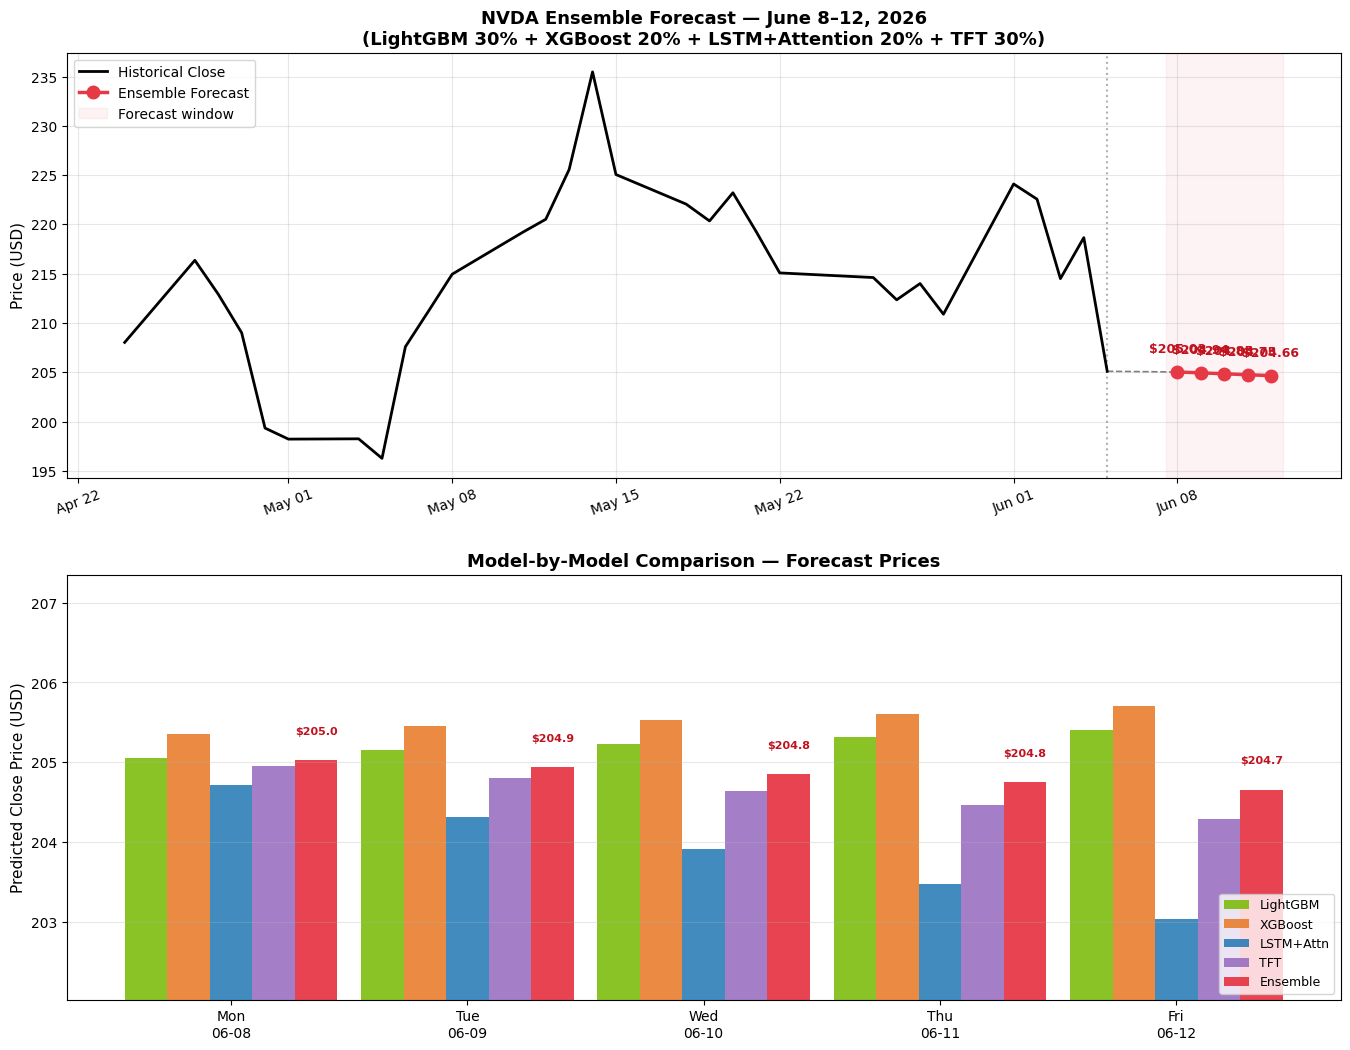

In [0]:
# Forecast Visualization

last_30     = lookback_df['Actual_Close'].tail(30)
ens_prices  = [row['ENSEMBLE ($)'] for row in final_predictions]

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ── TOP PANEL: Ensemble forecast ─────────────────────────────
ax = axes[0]

ax.plot(last_30.index, last_30.values,
        color='black', linewidth=2, label='Historical Close', zorder=3)

# Bridge line from last real point to first forecast
ax.plot([last_30.index[-1], bday_range[0]],
        [last_30.values[-1], ens_prices[0]],
        color='gray', linewidth=1.2, linestyle='--', zorder=2)

# Forecast line
ax.plot(bday_range, ens_prices,
        color='#e63946', linewidth=2.5, marker='o', markersize=9,
        label='Ensemble Forecast', zorder=5)

# Confidence band: ±1 std across the 4 model forecasts
for i, (date, row) in enumerate(zip(bday_range, final_predictions)):
    model_prices = [row['LightGBM ($)'], row['XGBoost ($)'],
                    row['LSTM ($)'], row['TFT ($)']]
    lo = min(model_prices)
    hi = max(model_prices)
    ax.fill_between([date, date], lo, hi,
                    color='#e63946', alpha=0.15, linewidth=0)

# Annotate each forecast point
for date, price in zip(bday_range, ens_prices):
    ax.annotate(f'${price:.2f}',
                xy=(date, price), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=9, fontweight='bold', color='#c1121f')

# Shade forecast zone
ax.axvspan(bday_range[0] - pd.Timedelta(hours=12),
           bday_range[-1] + pd.Timedelta(hours=12),
           alpha=0.06, color='#e63946', label='Forecast window')

ax.axvline(x=last_30.index[-1], color='gray', linestyle=':', alpha=0.6)
ax.set_title('NVDA Ensemble Forecast — June 8–12, 2026\n'
             '(LightGBM 30% + XGBoost 20% + LSTM+Attention 20% + TFT 30%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)

ax2 = axes[1]

day_labels  = [row['Day'][:3] + '\n' + row['Date'][5:] for row in final_predictions]
x_pos       = np.arange(FORECAST_DAYS)
bar_width   = 0.18

lgb_bars  = [row['LightGBM ($)'] for row in final_predictions]
xgb_bars  = [row['XGBoost ($)']  for row in final_predictions]
lstm_bars = [row['LSTM ($)']     for row in final_predictions]
tft_bars  = [row['TFT ($)']      for row in final_predictions]
ens_bars  = [row['ENSEMBLE ($)'] for row in final_predictions]

ax2.bar(x_pos - 2*bar_width, lgb_bars,  bar_width, label='LightGBM', color='#76b900', alpha=0.85)
ax2.bar(x_pos - bar_width,   xgb_bars,  bar_width, label='XGBoost',  color='#e87722', alpha=0.85)
ax2.bar(x_pos,               lstm_bars, bar_width, label='LSTM+Attn',color='#1f77b4', alpha=0.85)
ax2.bar(x_pos + bar_width,   tft_bars,  bar_width, label='TFT',       color='#9467bd', alpha=0.85)
ax2.bar(x_pos + 2*bar_width, ens_bars,  bar_width, label='Ensemble',  color='#e63946', alpha=0.95)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(day_labels, fontsize=10)
ax2.set_title('Model-by-Model Comparison — Forecast Prices', fontsize=13, fontweight='bold')
ax2.set_ylabel('Predicted Close Price (USD)', fontsize=11)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)

# Price labels on ensemble bars
for x, p in zip(x_pos + 2*bar_width, ens_bars):
    ax2.text(x, p + 0.3, f'${p:.1f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#c1121f')

# Dynamic y-axis range
all_vals = lgb_bars + xgb_bars + lstm_bars + tft_bars + ens_bars
ax2.set_ylim(min(all_vals) * 0.995, max(all_vals) * 1.008)

plt.tight_layout(pad=2.5)
plt.savefig('nvda_final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [0]:
# Print this after your forecasts run
print(f"Starting price: ${lookback_df['Actual_Close'].iloc[-1]:.2f}")
print(f"Day 5 prediction: ${final_predictions[4]['ENSEMBLE ($)']:.2f}")
change_pct = (final_predictions[4]['ENSEMBLE ($)'] / lookback_df['Actual_Close'].iloc[-1] - 1) * 100
print(f"Total 5-day change implied: {change_pct:+.1f}%")

Starting price: $205.10
Day 5 prediction: $204.66
Total 5-day change implied: -0.2%


In [0]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                  NVIDIA (NVDA) STOCK PRICE FORECAST                  ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEAM NICKNAME
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QuantX

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEAM MEMBERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Muhammad Haseeb Qamar   (148733)
""")

print("━" * 70)
print("3. FORECASTS — NVDA CLOSE PRICE (USD)")
print("━" * 70)
for row in final_predictions:
    print(f"   {row['Day']:<10}  {row['Date']}   ${row['ENSEMBLE ($)']:.2f}")

avg_forecast = sum(row['ENSEMBLE ($)'] for row in final_predictions) / len(final_predictions)
print("━" * 70)
print(f"   5-DAY AVERAGE FORECAST (8–12 June 2026):   ${avg_forecast:.2f}")
print("━" * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
METHOD DESCRIPTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   We built a 4-model ensemble with a stationary return-based prediction
   framework (models predict daily % returns, then prices are reconstructed
   as: Predicted_Close = Prior_Close × (1 + Predicted_Return)).

   MODEL 1 — LightGBM (weight 30%)
   Gradient Boosted Decision Trees trained on 40+ technical indicators
   plus 4-step structural lag features. Hyperparameters tuned with Optuna
   (50 trials, 5-fold walk-forward TimeSeriesSplit cross-validation).

   MODEL 2 — XGBoost (weight 20%)
   Independent gradient boosting model with separate Optuna tuning.
   Provides ensemble diversity via different tree-growth strategy.

   MODEL 3 — LSTM + Attention (weight 20%)
   2-layer Long Short-Term Memory network with Bahdanau attention.
   Input: 30-day sliding windows of 15 normalized features. Trained
   with HuberLoss, early stopping, and ReduceLROnPlateau scheduler.

   MODEL 4 — Temporal Fusion Transformer (weight 30%)
   Custom TFT-Lite with UpgradedVariableSelectionNetwork (dynamic
   per-timestep feature weighting), TransformerEncoder (4 attention
   heads, 2 layers), and Huber loss. State-of-the-art architecture
   for multi-horizon time-series forecasting.

   NLP SIGNAL — FinBERT Sentiment (feature for all models)
   ProsusAI/finbert applied to recent NVIDIA news from Yahoo Finance.
   Scores mapped to trading dates and merged as daily feature.

   VARIABLES: OHLCV, RSI(7,14), MACD+Signal+Histogram, Bollinger Bands
   (upper/lower/width/%B), ATR(14), Stochastic(K,D), ROC(5,10), EMA(9/21/50),
   SMA(20/50), ADX, OBV, VWAP, volume ratio, daily/log returns, High-Low%,
   Open-Close%, price vs MA ratios, lag features (1-4 steps × all features),
   rolling stats (5/10/20 days), calendar (DoW/Month/Quarter), FinBERT score.

   VALIDATION: Walk-forward TimeSeriesSplit (5 folds, no data leakage).
   TRAINING DATA: NVDA daily OHLCV, Yahoo Finance, Jan 2024 – Jun 2026.
   FORECAST METHOD: Recursive multi-step (5 steps, return-space prediction).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. CODE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   All code is in cells above. Running all cells top-to-bottom with
   DOWNLOAD_LIVE = False reproduces the exact forecasts shown in Section 3.

   Required packages: yfinance, lightgbm, xgboost, optuna, torch,
   transformers, ta, scikit-learn, pandas, numpy, matplotlib, seaborn
""")

# Model Performance Leaderboard
print("━" * 70)
print("  VALIDATION PERFORMANCE SUMMARY")
print("━" * 70)
results_table = pd.DataFrame({
    'Model'  : ['LightGBM', 'XGBoost', 'LSTM+Attention', 'TFT'],
    'MAE ($)': [round(lgb_mae, 4), round(xgb_mae, 4), round(lstm_mae, 4), round(tft_mae, 4)],
    'RMSE($)': [round(lgb_rmse, 4), round(xgb_rmse, 4), round(lstm_rmse, 4), round(tft_rmse, 4)],
    'R²'     : [round(lgb_r2, 4), round(xgb_r2, 4), round(lstm_r2, 4), round(tft_r2, 4)],
    'Weight' : ['30%', '20%', '20%', '30%']
})
print(results_table.to_string(index=False))
print("━" * 70)


╔══════════════════════════════════════════════════════════════════════╗
║                  NVIDIA (NVDA) STOCK PRICE FORECAST                  ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEAM NICKNAME
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QuantX

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEAM MEMBERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Muhammad Haseeb Qamar   (148733)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. FORECASTS — NVDA CLOSE PRICE (USD)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Monday      2026-06-08   $205.03
   Tuesday     2026-06-09   $204.94
   Wednesday   2026-06-10   $204.85
   Thursday    2026-06-11   $204.75
   Friday      2026-06-12   $204.66
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━